# Two-Stage Tabular Forecasting with a Compact Causal Feature Recipe

This notebook implements a **direct, non-sequential two-stage forecasting pipeline** for the MLPS power outage project.

The workflow stays aligned with the main project conventions:

- it uses the standard NetCDF training data and submission templates
- it preserves the **24-hour** and **48-hour** forecasting tasks
- it benchmarks against the baseline work
- it saves artifacts under `results/run_TIMESTAMP/`
- it is written to run both **locally** and in **Google Colab**

The key modeling idea is still a hurdle-style pipeline:

1. **Stage 1: classification**
   Predict whether the future outage at a given county-hour will be non-zero.
2. **Stage 2: regression**
   Predict the outage magnitude, conditional on the event being non-zero.
3. **Final forecast**
   Combine both stages as:

   `expected outage = P(non-zero) × E[outage | non-zero]`

This notebook uses a **compact causal feature recipe**:

- current outage at the forecast origin
- outage lag 1
- outage lag 24
- cyclical hour-of-day and day-of-week encodings
- a compact shortlist of weather variables

The validation setup is a single aligned forward split:

- training starts on **2023-06-01 00:00:00**
- the validation forecast origin is **2023-06-12 00:00:00**
- the 24h validation window spans the next 24 hourly targets
- the 48h validation window spans the next 48 hourly targets

This gives a clean apples-to-apples starting point for comparing a tabular two-stage model against a compact sequence-style feature recipe.

In [1]:
RUNNING_IN_COLAB = False
try:
    import google.colab  # type: ignore
    RUNNING_IN_COLAB = True
except ImportError:
    pass

if RUNNING_IN_COLAB:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive', force_remount=False)

import importlib
import subprocess
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'xarray': 'xarray',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'joblib': 'joblib',
    'scipy': 'scipy',
    'tqdm': 'tqdm',
    'xgboost': 'xgboost',
}

for module_name, package_name in required_packages.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        print(f'Installing missing dependency: {package_name}')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])

print('Dependency bootstrap complete.')


Mounted at /content/drive
Dependency bootstrap complete.


## Configuration

This notebook uses a single `config` dictionary for reproducibility and easy experimentation.

Compared with the heavier two-stage variants, this one keeps the feature recipe intentionally compact:

- outage now
- outage lag 1
- outage lag 24
- cyclical time encodings
- a shortlist of weather variables

The split is also fixed and explicit rather than discovered from the latest timestamps:

- training origins start at `2023-06-01 00:00:00`
- validation origin is `2023-06-12 00:00:00`

That keeps the run easy to reason about and makes comparisons much easier later.

In [2]:
import json
import math
import os
import platform
import random
import warnings
from collections import defaultdict
from copy import deepcopy
from datetime import datetime
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
)
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from tqdm.auto import tqdm

import xgboost as xgb

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 220)


def discover_project_root(running_in_colab: bool) -> Path:
    if running_in_colab:
        root = Path('/content/drive/MyDrive/MLPS Project')
        if not root.exists():
            raise FileNotFoundError(
                "Expected Colab project root '/content/drive/MyDrive/MLPS Project' was not found."
            )
        return root

    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'data' / 'train.nc').exists():
            return candidate

    raise FileNotFoundError(
        'Could not locate the project root. Make sure the current working directory is inside the MLPS project.'
    )


def detect_gpu() -> bool:
    try:
        import torch  # type: ignore
        return bool(torch.cuda.is_available())
    except Exception:
        pass

    try:
        completed = subprocess.run(
            ['nvidia-smi'],
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
            check=False,
        )
        return completed.returncode == 0
    except Exception:
        return False


PROJECT_ROOT = discover_project_root(RUNNING_IN_COLAB)
os.chdir(PROJECT_ROOT)

config = {
    # Whether this notebook is running inside Google Colab.
    'running_in_colab': RUNNING_IN_COLAB,
    # Random seed used for reproducibility.
    'seed': 2026,
    # Main modeling family. This notebook is built around a two-stage direct tabular hurdle pipeline.
    'model_family': 'direct_hurdle_tabular_compact_feature_recipe',
    # Forecast windows to evaluate and train. 24 means the next 24 hourly values; 48 means the next 48 hourly values.
    'horizons': [24, 48],
    # Use GPU acceleration when available. This only affects XGBoost; scikit-learn models remain CPU-based.
    'allow_gpu': True,
    # Number of CPU threads used by parallel-capable estimators.
    'n_jobs': 4,
    # Maximum training origins are sampled every N hours. Set to 1 to use every eligible origin inside the aligned training range.
    'origin_stride_hours': 1,
    # Minimum amount of history that must be available before the first training fold can start.
    'min_train_hours': 24 * 21,
    # Limit each fold to the most recent eligible training history so this notebook variant stays lightweight.
    'max_train_hours': 24 * 28,
    # Number of expanding-window backtest folds.
    'n_backtest_folds': 1,
    # Distance in hours between successive forecast origins in backtesting.
    'fold_spacing_hours': 24 * 14,
    # Manual single-fold splits keyed by horizon. These aligned splits override the default latest-window fold construction.
    'manual_backtest_splits': {
        24: {
            'train_origin_start': '2023-06-01 00:00:00',
            'val_origin_timestamp': '2023-06-12 00:00:00',
        },
        48: {
            'train_origin_start': '2023-06-01 00:00:00',
            'val_origin_timestamp': '2023-06-12 00:00:00',
        },
    },
    # Outage lag features, in hours, available to the tabular model at forecast time.
    'lag_hours': [1, 24],
    # Rolling windows, in hours, for outage and tracked summary statistics.
    'rolling_windows': [],
    # Weather lag features, in hours, made intentionally short in this notebook variant for faster runs.
    'weather_lags': [],
    # Rolling windows for weather summaries. Keeping only a short window here reduces feature growth and memory use.
    'weather_roll_windows': [],
    # Number of weather features kept after correlation screening.
    'n_weather_features': 10,
    # Whether county identity is explicitly one-hot encoded. Keeping this False mirrors the compact shared feature recipe.
    'include_location_feature': False,
    # Decision threshold used for classification reports and confusion matrices.
    'classifier_threshold': 0.50,
    # Stage-combination rule. The default computes the conditional expectation under the two-stage factorization.
    'combination_rule': 'probability_times_positive_expectation', # DESCRIPTIVE ONLY (no alternatives implemented)
    # Transform applied to the Stage 2 target. Log1p typically behaves better for heavy-tailed outage counts.
    'positive_target_transform': 'log1p', # DESCRIPTIVE ONLY (no alternatives implemented)
    # Numeric fill value used before optional scaling whenever lag or weather features remain missing after causal preprocessing.
    'numeric_missing_fill_value': 0.0,
    # Whether weather outlier handling is applied before feature engineering.
    'handle_weather_outliers': True,
    # Weather outlier strategy. clip_to_nan_then_linear_interpolate matches the compact causal cleaning recipe used here.
    'weather_outlier_strategy': 'clip_to_nan_then_linear_interpolate',
    # IQR multiplier used to define lower and upper weather bounds before interpolation.
    'weather_outlier_iqr_multiplier': 1.5,
    # Edge NaNs can remain after interpolation and are handled later by zero-fill preprocessing.
    'assert_no_weather_nans_after_cleaning': False,
    # Whether checkpoints should be reused when available.
    'resume_from_checkpoints': False,
    # Resume a specific existing results/run_TIMESTAMP directory instead of creating a fresh run.
    'resume_specific_run': False,
    # Timestamp token of the run directory to resume, without the 'run_' prefix.
    'resume_run_timestamp': '',
    # Reuse the latest results/run_TIMESTAMP directory only when no specific run is requested.
    'resume_latest_run': False,
    # Save fold-level trained models as well. This now writes reusable two-stage, classifier, and regressor bundles.
    'save_fold_models': True,
    # Persist every trained candidate and refit model as reusable joblib artifacts.
    'save_all_trained_models': True,
    # When checkpoints or dataset caches already exist, retrain only the missing model artifacts instead of recomputing full evaluations.
    'backfill_missing_model_artifacts_from_existing_runs': False,
    # Reuse already-saved model bundles whenever they exist and are valid.
    'reuse_existing_saved_models': False,
    # Reuse existing final refit bundles instead of retraining them when the rerun is only recovering missing artifacts.
    'reuse_existing_final_refit_artifacts': False,
    # Reuse canonical submission-model copies when they already exist.
    'reuse_existing_submission_model_artifacts': False,
    # Save canonical copies of the validation-selected submission bundles for easier downstream reuse.
    'save_submission_model_copies': True,
    # Use the best validation candidate model for the official submission files, while still saving separate refit predictions.
    'prediction_model_source': 'best_candidate_validation_model',
    # Evaluate on the provided demo test files if they exist. These are noisy demo targets, not the real hidden test labels.
    'use_demo_evaluation': True,
    # Number of counties to highlight in diagnostic plots.
    'plot_top_k_counties': 10,
    # Show nested classifier, regressor, and fold progress bars during backtesting.
    'show_detailed_progress': True,
    # Parameter grids for Stage 1 candidate models.
    'classifier_param_grid': {
        'logistic_enet': [
            {'C': 0.50, 'l1_ratio': 0.15, 'class_weight': 'balanced', 'max_iter': 250},
        ],
        'xgb_classifier': [
            {
                'n_estimators': 150,
                'learning_rate': 0.08,
                'max_depth': 5,
                'subsample': 0.80,
                'colsample_bytree': 0.70,
                'min_child_weight': 6,
                'reg_alpha': 0.00,
                'reg_lambda': 1.50,
                'early_stopping_rounds': 15,
            },
        ],
    },
    # Parameter grids for Stage 2 candidate models.
    'regressor_param_grid': {
        'elasticnet_regression': [
            {'alpha': 0.0005, 'l1_ratio': 0.10, 'max_iter': 4000},
        ],
        'xgb_regressor': [
            {
                'n_estimators': 200,
                'learning_rate': 0.06,
                'max_depth': 5,
                'subsample': 0.80,
                'colsample_bytree': 0.70,
                'min_child_weight': 6,
                'reg_alpha': 0.00,
                'reg_lambda': 1.50,
                'early_stopping_rounds': 15,
            },
        ],
    },
}

GPU_AVAILABLE = detect_gpu()
config['gpu_available'] = GPU_AVAILABLE
config['xgb_device'] = 'cuda' if (config['allow_gpu'] and GPU_AVAILABLE) else 'cpu'
config['xgb_tree_method'] = 'hist'

random.seed(config['seed'])
np.random.seed(config['seed'])

print(f'Project root: {PROJECT_ROOT}')
print(f'Running in Colab: {config["running_in_colab"]}')
print(f'GPU available: {config["gpu_available"]}')
print(f'XGBoost device: {config["xgb_device"]}')



Project root: /content/drive/MyDrive/MLPS Project
Running in Colab: True
GPU available: False
XGBoost device: cpu


## Reproducibility and artifact management

Every run creates a dedicated folder:

`results/run_YYYYMMDD_HHmmss/`

This folder stores:

- the experiment configuration
- environment information
- checkpoints for resume
- fold metrics
- plots
- trained final models
- submission CSVs
- a manifest of generated artifacts

The goal is simple: every run should be traceable, resumable, and easy to compare against earlier experiments.


In [3]:
RESULTS_ROOT = PROJECT_ROOT / 'results'
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)


def json_default(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.bool_,)):
        return bool(obj)
    if isinstance(obj, (pd.Timestamp, datetime)):
        return obj.isoformat()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if sparse.issparse(obj):
        return {'shape': obj.shape, 'nnz': int(obj.nnz)}
    return str(obj)


def make_json_safe_payload(payload):
    return json.loads(json.dumps(payload, default=json_default))


def list_existing_result_runs(results_root: Path) -> list[Path]:
    if not results_root.exists():
        return []

    timestamped_runs = []
    for run_dir in results_root.iterdir():
        if not run_dir.is_dir() or not run_dir.name.startswith('run_'):
            continue
        timestamp_token = run_dir.name[len('run_'):]
        try:
            parsed_timestamp = datetime.strptime(timestamp_token, '%Y%m%d_%H%M%S')
        except ValueError:
            continue
        timestamped_runs.append((parsed_timestamp, run_dir))

    return [run_dir for _, run_dir in sorted(timestamped_runs, key=lambda item: item[0])]


def validate_resume_run_config(config: dict, run_dir: Path):
    config_path = run_dir / 'config.json'
    if not config_path.exists():
        return

    with open(config_path, 'r', encoding='utf-8') as handle:
        previous_config = json.load(handle)

    current_config = make_json_safe_payload(config)
    comparable_keys = [
        'seed',
        'model_family',
        'horizons',
        'allow_gpu',
        'origin_stride_hours',
        'min_train_hours',
        'max_train_hours',
        'n_backtest_folds',
        'fold_spacing_hours',
        'manual_backtest_splits',
        'lag_hours',
        'rolling_windows',
        'weather_lags',
        'weather_roll_windows',
        'n_weather_features',
        'classifier_threshold',
        'combination_rule',
        'positive_target_transform',
        'classifier_param_grid',
        'regressor_param_grid',
    ]

    mismatches = []
    for key in comparable_keys:
        if previous_config.get(key) != current_config.get(key):
            mismatches.append(
                f'{key}: previous={previous_config.get(key)} | current={current_config.get(key)}'
            )

    if mismatches:
        mismatch_text = '\n'.join(mismatches)
        raise ValueError(
            'Cannot resume the latest run because resume-sensitive settings changed:\n'
            f'{mismatch_text}'
        )


def resolve_run_context(config: dict) -> dict:
    def start_new_run(reason: str | None = None) -> dict:
        if reason is not None:
            print(reason)
        run_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        run_dir = RESULTS_ROOT / f'run_{run_timestamp}'
        run_dir.mkdir(parents=True, exist_ok=True)
        return {
            'run_timestamp': run_timestamp,
            'run_dir': run_dir,
            'resumed_existing_run': False,
        }

    def resume_existing_run(run_dir: Path, description: str) -> dict:
        validate_resume_run_config(config, run_dir)
        print(f'Resuming {description} run directory: {run_dir}')
        return {
            'run_timestamp': run_dir.name[len('run_'):],
            'run_dir': run_dir,
            'resumed_existing_run': True,
        }

    specific_run_timestamp = str(config.get('resume_run_timestamp', '') or '').strip()
    if config.get('resume_specific_run', False):
        if not specific_run_timestamp:
            raise ValueError('resume_specific_run=True but resume_run_timestamp is empty.')
        specified_run_dir = RESULTS_ROOT / f'run_{specific_run_timestamp}'
        if not specified_run_dir.exists() or not specified_run_dir.is_dir():
            raise FileNotFoundError(
                f"resume_specific_run=True but the requested run directory was not found: {specified_run_dir}"
            )
        return resume_existing_run(specified_run_dir, 'specified')

    if not config.get('resume_latest_run', False):
        return start_new_run()

    existing_runs = list_existing_result_runs(RESULTS_ROOT)
    if not existing_runs:
        return start_new_run(
            'resume_latest_run=True but no previous results/run_TIMESTAMP directory was found. Starting a new run instead.'
        )

    latest_run_dir = existing_runs[-1]
    return resume_existing_run(latest_run_dir, 'latest')
RUN_CONTEXT = resolve_run_context(config)
RUN_TIMESTAMP = RUN_CONTEXT['run_timestamp']
RUN_DIR = RUN_CONTEXT['run_dir']
ARTIFACT_DIRS = {
    'run': RUN_DIR,
    'checkpoints': RUN_DIR / 'checkpoints',
    'metrics': RUN_DIR / 'metrics',
    'models': RUN_DIR / 'models',
    'plots': RUN_DIR / 'plots',
    'predictions': RUN_DIR / 'predictions',
    'tables': RUN_DIR / 'tables',
}

for path in ARTIFACT_DIRS.values():
    path.mkdir(parents=True, exist_ok=True)


def save_json(payload, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as handle:
        json.dump(payload, handle, indent=2, default=json_default)


def save_dataframe(df: pd.DataFrame, path: Path, index: bool = False):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=index)


config['run_timestamp'] = RUN_TIMESTAMP
config['run_dir'] = str(RUN_DIR)
config['resumed_existing_run'] = RUN_CONTEXT['resumed_existing_run']

environment_info = {
    'python_version': platform.python_version(),
    'platform': platform.platform(),
    'project_root': str(PROJECT_ROOT),
    'run_timestamp': RUN_TIMESTAMP,
    'resumed_existing_run': RUN_CONTEXT['resumed_existing_run'],
    'gpu_available': config['gpu_available'],
    'xgboost_device': config['xgb_device'],
    'package_versions': {
        'numpy': np.__version__,
        'pandas': pd.__version__,
        'xarray': xr.__version__,
        'matplotlib': plt.matplotlib.__version__,
        'seaborn': sns.__version__,
        'xgboost': xgb.__version__,
    },
}

save_json(config, ARTIFACT_DIRS['run'] / 'config.json')
save_json(environment_info, ARTIFACT_DIRS['run'] / 'environment.json')

print(f'Artifacts will be written to: {RUN_DIR}')
if RUN_CONTEXT['resumed_existing_run']:
    print('Existing run detected. Reusable artifacts from that folder will be preferred when available.')


Artifacts will be written to: /content/drive/MyDrive/MLPS Project/results/run_20260419_061735


## Data loading

We load the standard project assets:

- `data/train.nc`
- optional demo files `data/test_24h_demo.nc` and `data/test_48h_demo.nc`
- the submission templates

Even though the demo test files contain synthetic/noisy targets, they are still useful for:

- validating that the prediction pipeline runs end to end
- checking file shapes and timestamp alignment
- producing demo-only sanity metrics


In [4]:
# Reused project file layout from the earlier notebooks (`demo.ipynb`, `baseline_yuwenz.ipynb`,
# and `LSTM_model_qiushiw.ipynb`): the same root-level data files, demo test files, and submission templates.
TRAIN_PATH = PROJECT_ROOT / 'data' / 'train.nc'
TEST_24H_PATH = PROJECT_ROOT / 'data' / 'test_24h_demo.nc'
TEST_48H_PATH = PROJECT_ROOT / 'data' / 'test_48h_demo.nc'
TEMPLATE_24H_PATH = PROJECT_ROOT / 'submission_template_24h.csv'
TEMPLATE_48H_PATH = PROJECT_ROOT / 'submission_template_48h.csv'

ds_train = xr.open_dataset(TRAIN_PATH)
ds_test_24h = xr.open_dataset(TEST_24H_PATH) if TEST_24H_PATH.exists() else None
ds_test_48h = xr.open_dataset(TEST_48H_PATH) if TEST_48H_PATH.exists() else None

template_24 = pd.read_csv(TEMPLATE_24H_PATH)
template_48 = pd.read_csv(TEMPLATE_48H_PATH)

train_timestamps = pd.to_datetime(ds_train.timestamp.values)
locations = ds_train.location.values.astype(str).tolist()
weather_features = ds_train.feature.values.astype(str).tolist()

dataset_summary = pd.DataFrame(
    [
        {
            'n_locations': len(locations),
            'n_timestamps': len(train_timestamps),
            'n_weather_features': len(weather_features),
            'time_start': train_timestamps.min(),
            'time_end': train_timestamps.max(),
            'train_shape_out': tuple(ds_train.out.transpose('timestamp', 'location').shape),
            'train_shape_weather': tuple(ds_train.weather.transpose('timestamp', 'location', 'feature').shape),
        }
    ]
)

display(dataset_summary)
print('Template sizes:')
print(f'  24h template rows: {len(template_24):,}')
print(f'  48h template rows: {len(template_48):,}')


,n_locations,n_timestamps,n_weather_features,time_start,time_end,train_shape_out,train_shape_weather
0,83,2161,109,2023-04-01,2023-06-30,"(2161, 83)","(2161, 83, 109)"


Template sizes:
  24h template rows: 1,992
  48h template rows: 3,984


## First-pass EDA and task framing

Before we engineer lagged tabular features, it is useful to summarize the raw target:

- overall outage sparsity
- county-level heterogeneity
- heavy tails in outage counts

This matters for model choice:

- the sparsity motivates the two-stage design
- the heavy tails motivate the `log1p` transform for Stage 2
- county heterogeneity motivates keeping county identity as a feature


,metric,value
0,mean_outage,45.248334
1,median_outage,0.000000
2,std_outage,452.268440
3,max_outage,23346.000000
4,zero_rate,0.704733
5,nonzero_rate,0.295267


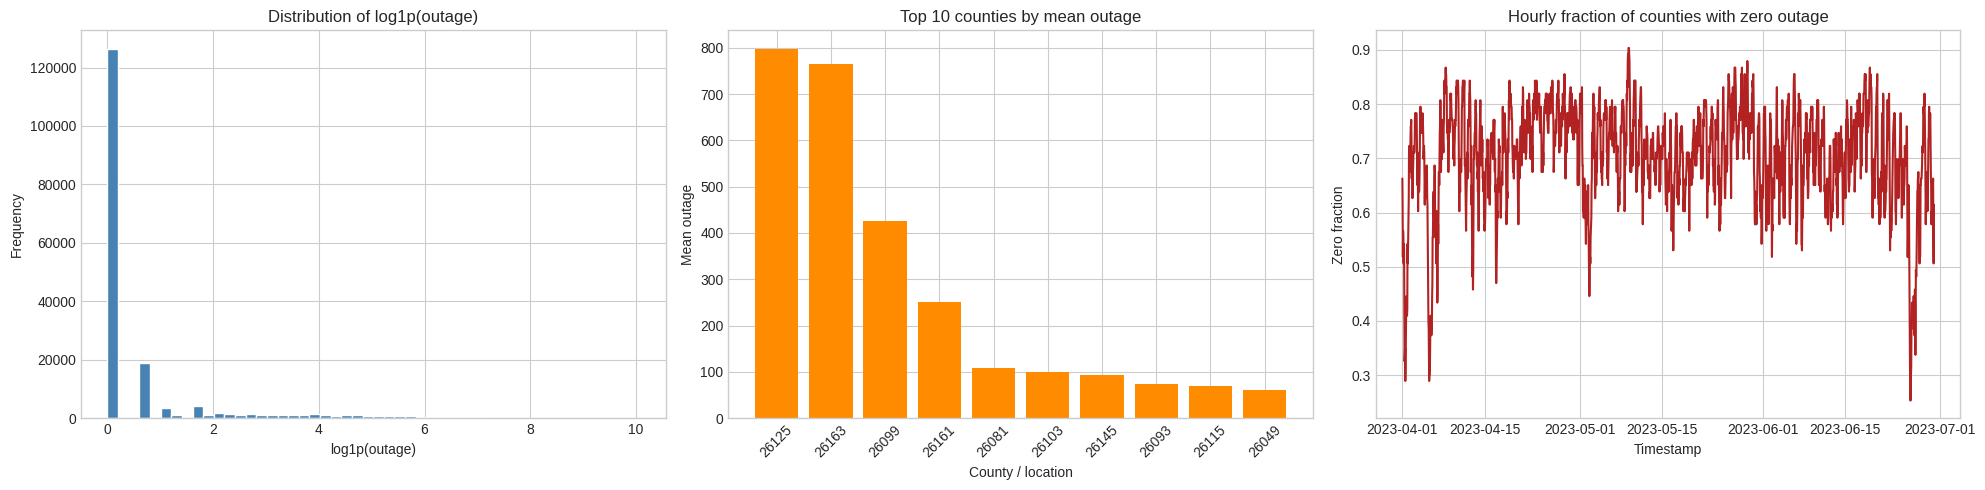

In [5]:
out_array = ds_train.out.transpose('timestamp', 'location').values.astype(float)
out_flat = out_array.reshape(-1)

eda_summary = pd.DataFrame(
    {
        'metric': [
            'mean_outage',
            'median_outage',
            'std_outage',
            'max_outage',
            'zero_rate',
            'nonzero_rate',
        ],
        'value': [
            float(np.mean(out_flat)),
            float(np.median(out_flat)),
            float(np.std(out_flat)),
            float(np.max(out_flat)),
            float(np.mean(out_flat == 0)),
            float(np.mean(out_flat > 0)),
        ],
    }
)
display(eda_summary)
save_dataframe(eda_summary, ARTIFACT_DIRS['tables'] / 'eda_summary.csv', index=False)

county_mean_out = ds_train.out.mean(dim='timestamp').to_pandas().sort_values(ascending=False)
top_counties = county_mean_out.head(config['plot_top_k_counties'])

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].hist(np.log1p(out_flat), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of log1p(outage)')
axes[0].set_xlabel('log1p(outage)')
axes[0].set_ylabel('Frequency')

axes[1].bar(top_counties.index.astype(str), top_counties.values, color='darkorange')
axes[1].set_title(f'Top {config["plot_top_k_counties"]} counties by mean outage')
axes[1].set_xlabel('County / location')
axes[1].set_ylabel('Mean outage')
axes[1].tick_params(axis='x', rotation=45)

hourly_zero_rate = pd.DataFrame(
    out_array == 0,
    index=train_timestamps,
    columns=locations,
).mean(axis=1)
axes[2].plot(train_timestamps, hourly_zero_rate, color='firebrick')
axes[2].set_title('Hourly fraction of counties with zero outage')
axes[2].set_xlabel('Timestamp')
axes[2].set_ylabel('Zero fraction')

plt.tight_layout()
plt.savefig(ARTIFACT_DIRS['plots'] / 'eda_overview.png', dpi=140)
plt.show()


## Cleaning strategy: compact causal preprocessing

This notebook uses a simple weather-cleaning pipeline before feature engineering:

1. **IQR-based outlier filtering** on weather variables
2. **Linear interpolation** over time for weather variables
3. Keep `out` and `tracked` unchanged

This approach is intentionally lightweight and causal:

- weather values are cleaned along the time axis
- the target series is never smoothed or altered
- any edge-case numeric gaps that remain after interpolation are handled later by the tabular preprocessing pipeline

The result is a compact starting point that keeps preprocessing understandable while avoiding brittle end-of-series failures.

Weather outlier filtering converted 694,226 values into NaN before interpolation.


,raw_weather_nan_count,post_outlier_filter_nan_count,post_interpolation_nan_count
0,0,694226,23654


Excluded all-zero weather features (28).


,feature,abs_corr_with_outage,signed_corr_with_outage
0,vstm,0.053937,-0.053937
1,unknown_2,0.052278,0.052278
2,veg,0.052249,0.052249
3,vvcsh,0.048789,-0.048789
4,unknown,0.043938,0.043938
5,v,0.042214,-0.042214
6,ustm,0.041538,-0.041538
7,mdens,0.040796,0.040796
8,vucsh,0.036464,-0.036464
9,lai,0.035000,0.035000


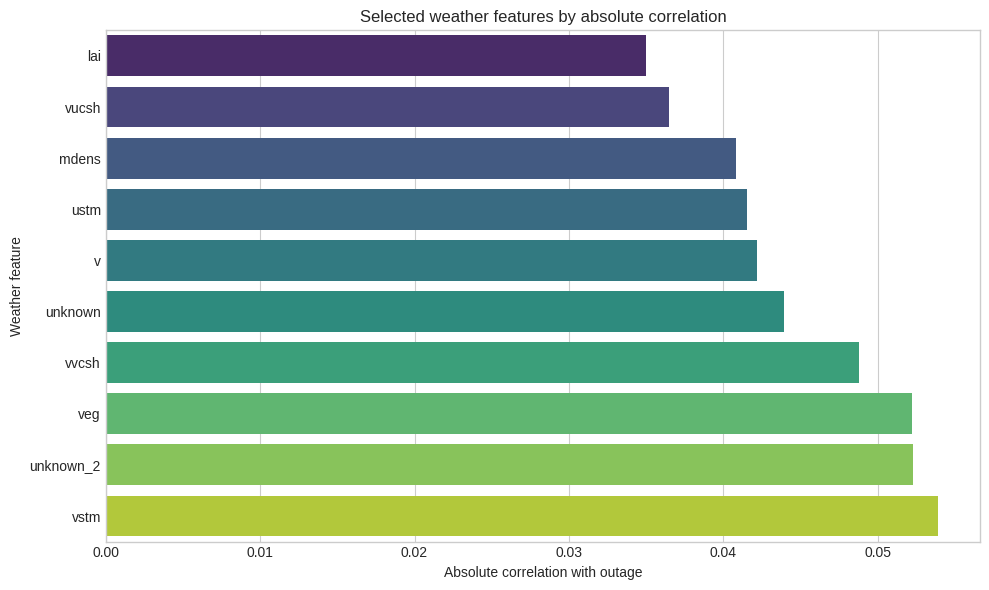

In [6]:
# Reused compact weather-cleaning pattern from the sequence-style notebook:
# out-of-range weather values become NaN first, then time interpolation repairs interior gaps.
weather = ds_train.weather.copy()

if config.get('handle_weather_outliers', True):
    Q1 = weather.quantile(0.25, dim='timestamp')
    Q3 = weather.quantile(0.75, dim='timestamp')
    IQR = Q3 - Q1
    iqr_multiplier = config.get('weather_outlier_iqr_multiplier', 1.5)
    lower = Q1 - iqr_multiplier * IQR
    upper = Q3 + iqr_multiplier * IQR

    if config.get('weather_outlier_strategy', 'clip_to_nan_then_linear_interpolate') != 'clip_to_nan_then_linear_interpolate':
        raise ValueError(
            f"Unsupported weather_outlier_strategy: {config.get('weather_outlier_strategy')}. "
            "Currently only 'clip_to_nan_then_linear_interpolate' is implemented in this notebook."
        )

    outlier_mask = (weather < lower) | (weather > upper)
    weather_clean = weather.where((weather >= lower) & (weather <= upper))
    print(
        f"Weather outlier filtering converted {int(outlier_mask.sum().item()):,} values into NaN "
        "before interpolation."
    )
else:
    weather_clean = weather
    print('Weather outlier handling is disabled; raw weather values are being used.')

weather_filled = weather_clean.interpolate_na(dim='timestamp', method='linear')

weather_cleaning_summary = pd.DataFrame(
    [
        {
            'raw_weather_nan_count': int(weather.isnull().sum().item()),
            'post_outlier_filter_nan_count': int(weather_clean.isnull().sum().item()),
            'post_interpolation_nan_count': int(weather_filled.isnull().sum().item()),
        }
    ]
)
display(weather_cleaning_summary)
save_dataframe(weather_cleaning_summary, ARTIFACT_DIRS['tables'] / 'weather_cleaning_summary.csv', index=False)

ds_train_clean = xr.Dataset(
    {
        'weather': weather_filled,
        'tracked': ds_train.tracked,
        'out': ds_train.out,
    },
    coords={
        'location': ds_train.location,
        'timestamp': ds_train.timestamp,
        'feature': ds_train.feature,
    },
)

weather_feature_names = ds_train_clean.feature.values.astype(str).tolist()
weather_flat = (
    ds_train_clean.weather
    .transpose('timestamp', 'location', 'feature')
    .values.astype(float)
    .reshape(-1, len(weather_feature_names))
)

all_zero_mask = np.all(np.nan_to_num(weather_flat, nan=0.0) == 0.0, axis=0)
zero_features = [weather_feature_names[i] for i in range(len(weather_feature_names)) if all_zero_mask[i]]
non_zero_features = [feature for feature in weather_feature_names if feature not in zero_features]

print(f'Excluded all-zero weather features ({len(zero_features)}).')

out_flat = ds_train.out.values.astype(float).reshape(-1)
weather_corr_df = pd.DataFrame(weather_flat, columns=weather_feature_names)
weather_corr_df['out'] = out_flat

target_corr = weather_corr_df[non_zero_features + ['out']].corr(numeric_only=True)['out'].drop('out')
nan_corr_features = target_corr[target_corr.isna()].index.tolist()
valid_features = [feature for feature in non_zero_features if feature not in nan_corr_features]

if not len(valid_features):
    raise ValueError('No valid weather features remained after all-zero and NaN-correlation screening.')

target_corr_valid = target_corr[valid_features].abs().sort_values(ascending=False)
selected_weather_features = target_corr_valid.head(config['n_weather_features']).index.tolist()

selected_weather_df = pd.DataFrame(
    {
        'feature': selected_weather_features,
        'abs_corr_with_outage': target_corr.loc[selected_weather_features].abs().values,
        'signed_corr_with_outage': target_corr.loc[selected_weather_features].values,
    }
)
display(selected_weather_df)
save_dataframe(selected_weather_df, ARTIFACT_DIRS['tables'] / 'selected_weather_features.csv', index=False)
save_json(
    {
        'selected_weather_features': selected_weather_features,
        'excluded_all_zero_features': zero_features,
        'excluded_nan_correlation_features': nan_corr_features,
    },
    ARTIFACT_DIRS['run'] / 'selected_weather_features.json',
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=selected_weather_df.sort_values('abs_corr_with_outage', ascending=True),
    x='abs_corr_with_outage',
    y='feature',
    palette='viridis',
    ax=ax,
)
ax.set_title('Selected weather features by absolute correlation')
ax.set_xlabel('Absolute correlation with outage')
ax.set_ylabel('Weather feature')
plt.tight_layout()
plt.savefig(ARTIFACT_DIRS['plots'] / 'selected_weather_features.png', dpi=140)
plt.show()

## Forecasting design: compact direct tabular features

### Core idea

We still formulate the problem as a **forecast-origin dataset**:

- each row corresponds to a county at a particular forecast origin
- features use only information available **up to that origin**
- targets are the future outages at `t + 1`, `t + 2`, ..., `t + H`

### Feature recipe used here

To keep this notebook compact and easy to compare, the base feature block contains:

- current outage
- outage lag 1
- outage lag 24
- cyclical hour-of-day encodings
- cyclical day-of-week encodings
- the selected weather variables at the forecast origin

No rolling windows are added in this notebook variant, and no extra tracked-feature summaries are added either.

### Why keep `horizon_step` as a feature?

Instead of training one separate model for every single horizon step, we stack the training rows and include:

- `horizon_step`
- target timestamp calendar features

This lets one model family learn a shared structure across the whole 24h or 48h validation window while keeping the feature recipe itself compact.

In [7]:
MAX_HORIZON = max(config['horizons'])


def add_cyclical_time_features(df: pd.DataFrame, timestamp_col: str, prefix: str) -> pd.DataFrame:
    ts = pd.to_datetime(df[timestamp_col])
    df[f'{prefix}_hour_sin'] = np.sin(2 * np.pi * ts.dt.hour / 24.0)
    df[f'{prefix}_hour_cos'] = np.cos(2 * np.pi * ts.dt.hour / 24.0)
    df[f'{prefix}_dow_sin'] = np.sin(2 * np.pi * ts.dt.dayofweek / 7.0)
    df[f'{prefix}_dow_cos'] = np.cos(2 * np.pi * ts.dt.dayofweek / 7.0)
    return df


def build_compact_feature_frame(
    ds_clean: xr.Dataset,
    timestamps: pd.Index,
    selected_weather_features: list[str],
) -> pd.DataFrame:
    out_vals = ds_clean.out.transpose('timestamp', 'location').values.astype(float)
    n_timestamps, n_locations = out_vals.shape
    location_values = ds_clean.location.values.astype(str)

    def lag_matrix(arr: np.ndarray, lag_hours: int) -> np.ndarray:
        shifted = np.full_like(arr, np.nan)
        shifted[lag_hours:] = arr[:-lag_hours]
        return shifted

    lag_1 = lag_matrix(out_vals, 1)
    lag_24 = lag_matrix(out_vals, 24)

    hour_sin = np.sin(2 * np.pi * timestamps.hour / 24.0).values[:, None] * np.ones((1, n_locations))
    hour_cos = np.cos(2 * np.pi * timestamps.hour / 24.0).values[:, None] * np.ones((1, n_locations))
    dow_sin = np.sin(2 * np.pi * timestamps.dayofweek / 7.0).values[:, None] * np.ones((1, n_locations))
    dow_cos = np.cos(2 * np.pi * timestamps.dayofweek / 7.0).values[:, None] * np.ones((1, n_locations))

    weather_vals = (
        ds_clean.weather
        .sel(feature=selected_weather_features)
        .transpose('timestamp', 'location', 'feature')
        .values.astype(float)
    )

    model_df = pd.DataFrame(
        {
            'timestamp': np.repeat(timestamps.values, n_locations),
            'location': np.tile(location_values, n_timestamps),
            'out': out_vals.reshape(-1),
            'out_curr': out_vals.reshape(-1),
            'out_lag_1': lag_1.reshape(-1),
            'out_lag_24': lag_24.reshape(-1),
            'origin_hour_sin': hour_sin.reshape(-1),
            'origin_hour_cos': hour_cos.reshape(-1),
            'origin_dow_sin': dow_sin.reshape(-1),
            'origin_dow_cos': dow_cos.reshape(-1),
        }
    )

    for feature_index, feature_name in enumerate(selected_weather_features):
        model_df[feature_name] = weather_vals[:, :, feature_index].reshape(-1)

    model_df['timestamp'] = pd.to_datetime(model_df['timestamp'])
    model_df['location'] = model_df['location'].astype(str)
    model_df = model_df.sort_values(['location', 'timestamp']).reset_index(drop=True)
    return model_df

In [8]:
model_df = build_compact_feature_frame(ds_train_clean, train_timestamps, selected_weather_features)

# Reused direct-target construction from the earlier two-stage notebooks:
# build future targets once and then train separate 24h and 48h forecasting tasks from the same base frame.
for horizon_step in range(1, MAX_HORIZON + 1):
    model_df[f'target_out_t_plus_{horizon_step}'] = model_df.groupby('location')['out'].shift(-horizon_step)

all_timestamps = pd.Index(sorted(model_df['timestamp'].unique()))
timestamp_to_idx = {timestamp: idx for idx, timestamp in enumerate(all_timestamps)}
model_df['global_time_idx'] = model_df['timestamp'].map(timestamp_to_idx).astype(int)

target_cols_all = [f'target_out_t_plus_{h}' for h in range(1, MAX_HORIZON + 1)]

base_numeric_feature_cols = [
    column
    for column in model_df.columns
    if column not in {'location', 'timestamp', 'out', 'global_time_idx'}
    and column not in target_cols_all
]
categorical_feature_cols = ['location'] if config.get('include_location_feature', False) else []

feature_warmup = max(config['lag_hours']) if len(config['lag_hours']) else 0

feature_frame_summary = pd.DataFrame(
    {
        'metric': [
            'rows_in_model_df',
            'base_numeric_features',
            'categorical_features',
            'feature_warmup_hours',
            'max_horizon',
            'selected_weather_feature_count',
        ],
        'value': [
            int(len(model_df)),
            int(len(base_numeric_feature_cols)),
            int(len(categorical_feature_cols)),
            int(feature_warmup),
            int(MAX_HORIZON),
            int(len(selected_weather_features)),
        ],
    }
)
display(feature_frame_summary)
save_dataframe(feature_frame_summary, ARTIFACT_DIRS['tables'] / 'feature_frame_summary.csv', index=False)

,metric,value
0,rows_in_model_df,179363
1,base_numeric_features,17
2,categorical_features,0
3,feature_warmup_hours,24
4,max_horizon,48
5,selected_weather_feature_count,10


## Validation strategy: one explicit forward split

This notebook uses a single explicit forward validation split.

For both horizons:

- training origins start at **2023-06-01 00:00:00**
- validation origin is **2023-06-12 00:00:00**

Then the future target windows are:

- **24h validation:** the 24 hourly targets after that origin
- **48h validation:** the 48 hourly targets after that origin

As in the other direct-forecast notebooks, the last admissible training origin is clipped automatically so no training target spills into the validation window.

,horizon,fold_id,val_origin_idx,val_origin_timestamp,train_origin_start_idx,train_origin_start_timestamp,train_origin_max_idx,train_origin_max_timestamp,validation_window_start,validation_window_end
0,24,1,1728,2023-06-12,1464,2023-06-01,1704,2023-06-11,2023-06-12 01:00:00,2023-06-13
1,48,1,1728,2023-06-12,1464,2023-06-01,1680,2023-06-10,2023-06-12 01:00:00,2023-06-14


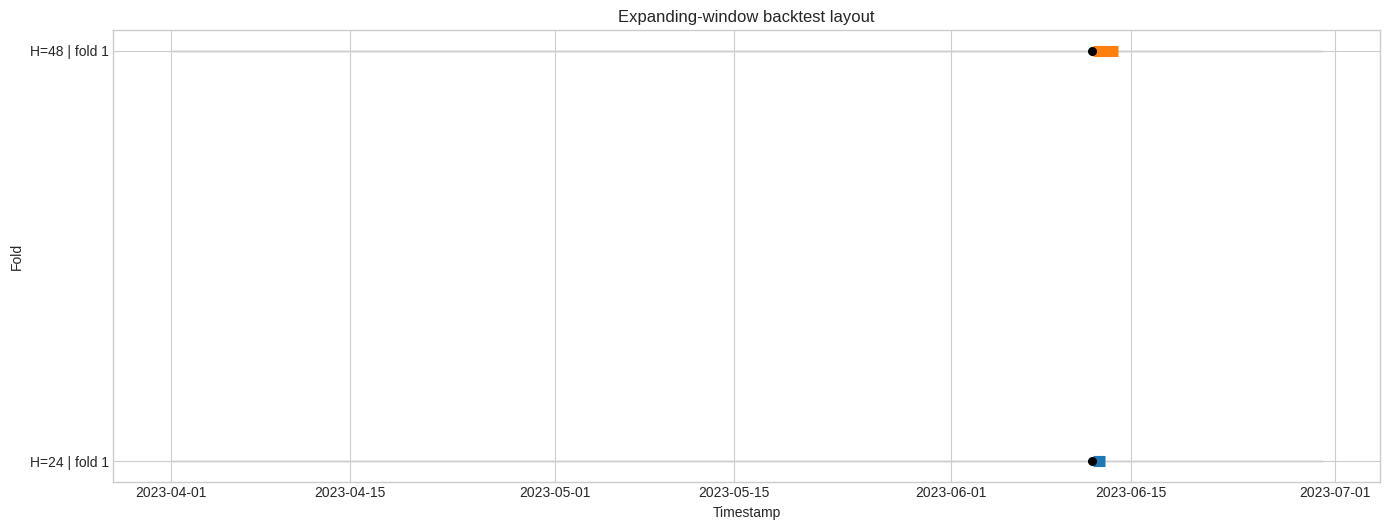

In [9]:
def make_backtest_folds(
    all_timestamps: pd.Index,
    horizon: int,
    feature_warmup: int,
    min_train_hours: int,
    n_folds: int,
    fold_spacing_hours: int,
    manual_split=None,
):
    if manual_split is not None:
        val_origin_timestamp = pd.Timestamp(manual_split['val_origin_timestamp'])
        train_origin_start_timestamp = pd.Timestamp(manual_split['train_origin_start'])

        if val_origin_timestamp not in all_timestamps:
            raise ValueError(f'Manual validation origin timestamp not found in training timestamps: {val_origin_timestamp}')
        if train_origin_start_timestamp not in all_timestamps:
            raise ValueError(f'Manual training start timestamp not found in training timestamps: {train_origin_start_timestamp}')

        val_origin_idx = int(all_timestamps.get_loc(val_origin_timestamp))
        train_origin_max_idx = val_origin_idx - horizon
        train_origin_start_idx = max(feature_warmup, int(all_timestamps.get_loc(train_origin_start_timestamp)))

        if train_origin_max_idx < train_origin_start_idx:
            raise ValueError(
                f'Manual split for horizon {horizon} is inconsistent: '
                f'train start {all_timestamps[train_origin_start_idx]} is later than the last eligible training origin {all_timestamps[train_origin_max_idx]}'
            )

        return [
            {
                'fold_id': 1,
                'val_origin_idx': int(val_origin_idx),
                'val_origin_timestamp': pd.Timestamp(all_timestamps[val_origin_idx]),
                'train_origin_start_idx': int(train_origin_start_idx),
                'train_origin_start_timestamp': pd.Timestamp(all_timestamps[train_origin_start_idx]),
                'train_origin_max_idx': int(train_origin_max_idx),
                'train_origin_max_timestamp': pd.Timestamp(all_timestamps[train_origin_max_idx]),
                'validation_window_start': pd.Timestamp(all_timestamps[val_origin_idx + 1]),
                'validation_window_end': pd.Timestamp(all_timestamps[val_origin_idx + horizon]),
            }
        ]

    latest_validation_origin_idx = len(all_timestamps) - horizon - 1
    proposed_indices = [
        latest_validation_origin_idx - fold_spacing_hours * offset
        for offset in range(n_folds - 1, -1, -1)
    ]

    folds = []
    for fold_number, val_origin_idx in enumerate(proposed_indices, start=1):
        train_origin_max_idx = val_origin_idx - horizon
        min_required_idx = feature_warmup + min_train_hours
        if train_origin_max_idx < min_required_idx:
            continue

        folds.append(
            {
                'fold_id': fold_number,
                'val_origin_idx': int(val_origin_idx),
                'val_origin_timestamp': pd.Timestamp(all_timestamps[val_origin_idx]),
                'train_origin_max_idx': int(train_origin_max_idx),
                'train_origin_max_timestamp': pd.Timestamp(all_timestamps[train_origin_max_idx]),
                'validation_window_start': pd.Timestamp(all_timestamps[val_origin_idx + 1]),
                'validation_window_end': pd.Timestamp(all_timestamps[val_origin_idx + horizon]),
            }
        )

    return folds


fold_registry = {}
fold_rows = []
for horizon in [24, 48]:
    # Reused task split convention from the earlier project notebooks:
    # keep explicit 24-hour and 48-hour evaluation tracks.
    folds = make_backtest_folds(
        all_timestamps=all_timestamps,
        horizon=horizon,
        feature_warmup=feature_warmup,
        min_train_hours=config['min_train_hours'],
        n_folds=config['n_backtest_folds'],
        fold_spacing_hours=config['fold_spacing_hours'],
        manual_split=config.get('manual_backtest_splits', {}).get(horizon),
    )
    fold_registry[horizon] = folds
    for fold in folds:
        fold_rows.append({'horizon': horizon, **fold})

fold_df = pd.DataFrame(fold_rows)
display(fold_df)
save_dataframe(fold_df, ARTIFACT_DIRS['tables'] / 'backtest_folds.csv', index=False)

fig, ax = plt.subplots(figsize=(14, 3 + 1.2 * max(1, len(fold_df))))
color_map = {24: '#1f77b4', 48: '#ff7f0e'}
y_positions = np.arange(len(fold_df))

for row_idx, row in fold_df.reset_index(drop=True).iterrows():
    ax.plot([train_timestamps.min(), train_timestamps.max()], [row_idx, row_idx], color='lightgray', linewidth=2, alpha=0.5)
    ax.plot(
        [row['validation_window_start'], row['validation_window_end']],
        [row_idx, row_idx],
        color=color_map[row['horizon']],
        linewidth=8,
        solid_capstyle='butt',
    )
    ax.scatter(row['val_origin_timestamp'], row_idx, color='black', s=30, zorder=3)

ax.set_yticks(y_positions)
ax.set_yticklabels([f"H={row['horizon']} | fold {row['fold_id']}" for _, row in fold_df.reset_index(drop=True).iterrows()])
ax.set_title('Expanding-window backtest layout')
ax.set_xlabel('Timestamp')
ax.set_ylabel('Fold')
plt.tight_layout()
plt.savefig(ARTIFACT_DIRS['plots'] / 'backtest_layout.png', dpi=140)
plt.show()


## Modeling utilities

This section defines the reusable training functions for:

- feature preprocessing
- Stage 1 model fitting
- Stage 2 model fitting
- fold-level evaluation
- checkpoint reuse

The code is intentionally modular so you can replace pieces later:

- add a new classifier family
- add a new regressor
- change the combination rule
- move from sparse one-hot encoding to target encoding or embeddings


In [10]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=True)


def add_target_time_features(df: pd.DataFrame) -> pd.DataFrame:
    target_ts = pd.to_datetime(df['target_timestamp'])
    df['horizon_step'] = df['horizon_step'].astype(int)
    df['target_hour'] = target_ts.dt.hour
    df['target_dow'] = target_ts.dt.dayofweek
    df['target_month'] = target_ts.dt.month
    df['target_hour_sin'] = np.sin(2 * np.pi * df['target_hour'] / 24.0)
    df['target_hour_cos'] = np.cos(2 * np.pi * df['target_hour'] / 24.0)
    df['target_dow_sin'] = np.sin(2 * np.pi * df['target_dow'] / 7.0)
    df['target_dow_cos'] = np.cos(2 * np.pi * df['target_dow'] / 7.0)
    df['forecast_day_offset'] = ((df['horizon_step'] - 1) // 24).astype(int)
    return df


dynamic_numeric_feature_cols = [
    'horizon_step',
    'target_hour',
    'target_dow',
    'target_month',
    'target_hour_sin',
    'target_hour_cos',
    'target_dow_sin',
    'target_dow_cos',
    'forecast_day_offset',
]


In [11]:
def build_stacked_dataset(base_df: pd.DataFrame, origin_indices: list[int], horizon: int) -> pd.DataFrame:
    target_cols = [f'target_out_t_plus_{step}' for step in range(1, horizon + 1)]
    keep_cols = ['location', 'timestamp', 'global_time_idx'] + base_numeric_feature_cols + target_cols
    subset = base_df.loc[base_df['global_time_idx'].isin(origin_indices), keep_cols].copy()
    # Keep rows with partially available past-based features and let the zero-fill preprocessing pipeline handle them.
    # Only rows without the farthest supervised target for this horizon must be excluded.
    subset = subset.dropna(subset=[target_cols[-1]])

    stacked = subset.melt(
        id_vars=['location', 'timestamp', 'global_time_idx'] + base_numeric_feature_cols,
        value_vars=target_cols,
        var_name='target_col',
        value_name='target_out',
    )
    stacked['horizon_step'] = stacked['target_col'].str.extract(r'(\d+)').astype(int)
    stacked = stacked.drop(columns=['target_col'])
    stacked['target_timestamp'] = pd.to_datetime(stacked['timestamp']) + pd.to_timedelta(stacked['horizon_step'], unit='h')
    stacked = add_target_time_features(stacked)
    stacked['target_nonzero'] = (stacked['target_out'] > 0).astype(int)
    stacked['location'] = stacked['location'].astype(str)
    return stacked.reset_index(drop=True)


def get_fold_dataset(horizon: int, fold: dict) -> dict:
    dataset_cache_path = ARTIFACT_DIRS['checkpoints'] / f'h{horizon}_fold{fold["fold_id"]}_datasets.joblib'
    if config['resume_from_checkpoints'] and dataset_cache_path.exists():
        return joblib.load(dataset_cache_path)

    explicit_train_start_idx = fold.get('train_origin_start_idx')
    if explicit_train_start_idx is not None and not pd.isna(explicit_train_start_idx):
        recent_train_start_idx = max(feature_warmup, int(explicit_train_start_idx))
    elif config['max_train_hours'] is None:
        recent_train_start_idx = feature_warmup
    else:
        recent_train_start_idx = max(
            feature_warmup,
            fold['train_origin_max_idx'] - config['max_train_hours'] + 1,
        )
    train_origin_indices = list(range(recent_train_start_idx, fold['train_origin_max_idx'] + 1, config['origin_stride_hours']))
    valid_origin_indices = [fold['val_origin_idx']]

    bundle = {
        'train': build_stacked_dataset(model_df, train_origin_indices, horizon),
        'valid': build_stacked_dataset(model_df, valid_origin_indices, horizon),
        'train_origin_indices': train_origin_indices,
        'valid_origin_indices': valid_origin_indices,
    }
    joblib.dump(bundle, dataset_cache_path, compress=3)
    return bundle


def fit_preprocessor(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    numeric_cols: list[str],
    categorical_cols: list[str],
    scale_numeric: bool,
):
    numeric_steps = [('imputer', SimpleImputer(strategy='constant', fill_value=config.get('numeric_missing_fill_value', 0.0), add_indicator=True))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))
    numeric_transformer = Pipeline(steps=numeric_steps)
    transformers = [('num', numeric_transformer, numeric_cols)]
    if len(categorical_cols):
        transformers.append(('cat', make_one_hot_encoder(), categorical_cols))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop',
        sparse_threshold=1.0,
    )

    train_view = train_df[numeric_cols + categorical_cols].copy()
    valid_view = valid_df[numeric_cols + categorical_cols].copy()

    X_train = preprocessor.fit_transform(train_view)
    X_valid = preprocessor.transform(valid_view)
    feature_names = preprocessor.get_feature_names_out().tolist()
    return preprocessor, X_train, X_valid, feature_names


def safe_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def safe_average_precision(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return average_precision_score(y_true, y_score)


def classification_metrics_dict(y_true, proba, threshold: float) -> dict:
    pred = (proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    metrics = {
        'roc_auc': safe_auc(y_true, proba),
        'average_precision': safe_average_precision(y_true, proba),
        'brier_score': brier_score_loss(y_true, proba),
        'log_loss': log_loss(y_true, np.clip(proba, 1e-6, 1 - 1e-6), labels=[0, 1]),
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f1': f1_score(y_true, pred, zero_division=0),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }
    return metrics


def rmse(y_true, y_pred) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def average_county_rmse(df: pd.DataFrame, prediction_col: str) -> float:
    county_rmse = []
    for _, group in df.groupby('location'):
        county_rmse.append(rmse(group['target_out'].values, group[prediction_col].values))
    return float(np.mean(county_rmse))


def make_param_signature(params: dict) -> str:
    return json.dumps(params, sort_keys=True, default=json_default)


MODEL_NAME_SHORT = {
    'logistic_enet': 'logen',
    'xgb_classifier': 'xgbc',
    'elasticnet_regression': 'enet',
    'xgb_regressor': 'xgbr',
}


def build_model_alias_lookup(role_prefix: str, model_param_grid: dict) -> dict:
    alias_lookup = {}
    for model_name, grid in model_param_grid.items():
        short_name = MODEL_NAME_SHORT.get(model_name, model_name.replace('_', '')[:6])
        for index, params in enumerate(grid, start=1):
            signature = (model_name, make_param_signature(params))
            alias_lookup[signature] = f'{role_prefix}_{short_name}{index:02d}'
    return alias_lookup


CLASSIFIER_ALIAS_LOOKUP = build_model_alias_lookup('clf', config['classifier_param_grid'])
REGRESSOR_ALIAS_LOOKUP = build_model_alias_lookup('reg', config['regressor_param_grid'])


def make_model_tag(model_name: str, params: dict, role: str) -> str:
    signature = (model_name, make_param_signature(params))
    lookup = CLASSIFIER_ALIAS_LOOKUP if role == 'classifier' else REGRESSOR_ALIAS_LOOKUP
    if signature not in lookup:
        raise KeyError(f'No alias was registered for {role} model {model_name} with params {params}')
    return lookup[signature]


def make_legacy_model_tag(model_name: str, params: dict) -> str:
    pieces = [model_name]
    for key, value in params.items():
        pieces.append(f'{key}={value}')
    raw = '__'.join(pieces)
    return raw.replace('/', '-').replace(' ', '')


def make_pair_tag(horizon: int, classifier_name: str, classifier_params: dict, regressor_name: str, regressor_params: dict) -> str:
    classifier_tag = make_model_tag(classifier_name, classifier_params, role='classifier')
    regressor_tag = make_model_tag(regressor_name, regressor_params, role='regressor')
    return f'h{horizon}__{classifier_tag}__{regressor_tag}'


def make_legacy_pair_tag(horizon: int, classifier_name: str, classifier_params: dict, regressor_name: str, regressor_params: dict) -> str:
    return (
        f'h{horizon}__{make_legacy_model_tag(classifier_name, classifier_params)}'
        f'__{make_legacy_model_tag(regressor_name, regressor_params)}'
    )


def get_pair_artifact_paths(pair_tag: str, fold_id: int | None = None) -> dict:
    paths = {
        'checkpoint': ARTIFACT_DIRS['checkpoints'] / f'pair_{pair_tag}.joblib',
        'fold_metrics': ARTIFACT_DIRS['metrics'] / f'pair_{pair_tag}_fold_metrics.csv',
        'stage1_feature_signal': ARTIFACT_DIRS['tables'] / f'pair_{pair_tag}_stage1_feature_signal.csv',
        'stage2_feature_signal': ARTIFACT_DIRS['tables'] / f'pair_{pair_tag}_stage2_feature_signal.csv',
    }
    if fold_id is not None:
        paths.update(
            {
                'validation_predictions': ARTIFACT_DIRS['predictions'] / f'pair_{pair_tag}_f{fold_id:02d}_val_predictions.csv',
                'stage1_history': ARTIFACT_DIRS['metrics'] / f'pair_{pair_tag}_f{fold_id:02d}_stage1_history.json',
                'stage2_history': ARTIFACT_DIRS['metrics'] / f'pair_{pair_tag}_f{fold_id:02d}_stage2_history.json',
                'two_stage_model': ARTIFACT_DIRS['models'] / f'pair_{pair_tag}_f{fold_id:02d}_two_stage.joblib',
                'stage1_model': ARTIFACT_DIRS['models'] / f'pair_{pair_tag}_f{fold_id:02d}_stage1_classifier.joblib',
                'stage2_model': ARTIFACT_DIRS['models'] / f'pair_{pair_tag}_f{fold_id:02d}_stage2_regressor.joblib',
            }
        )
    return paths


def get_legacy_pair_artifact_paths(legacy_pair_tag: str, fold_id: int | None = None) -> dict:
    paths = {
        'checkpoint': ARTIFACT_DIRS['checkpoints'] / f'{legacy_pair_tag}.joblib',
        'fold_metrics': ARTIFACT_DIRS['metrics'] / f'{legacy_pair_tag}__fold_metrics.csv',
        'stage1_feature_signal': ARTIFACT_DIRS['tables'] / f'{legacy_pair_tag}__stage1_feature_signal.csv',
        'stage2_feature_signal': ARTIFACT_DIRS['tables'] / f'{legacy_pair_tag}__stage2_feature_signal.csv',
    }
    if fold_id is not None:
        paths.update(
            {
                'validation_predictions': ARTIFACT_DIRS['predictions'] / f'{legacy_pair_tag}__fold{fold_id}_validation_predictions.csv',
                'stage1_history': ARTIFACT_DIRS['metrics'] / f'{legacy_pair_tag}__fold{fold_id}_stage1_history.json',
                'stage2_history': ARTIFACT_DIRS['metrics'] / f'{legacy_pair_tag}__fold{fold_id}_stage2_history.json',
            }
        )
    return paths


def is_nonempty_file(path: Path) -> bool:
    return path.exists() and path.is_file() and path.stat().st_size > 0


def remove_file_if_exists(path: Path):
    try:
        if path.exists() and path.is_file():
            path.unlink()
    except FileNotFoundError:
        pass


def is_valid_csv_artifact(path: Path, required_columns: set[str], min_rows: int = 1) -> bool:
    if not is_nonempty_file(path):
        return False
    try:
        sample = pd.read_csv(path, nrows=max(1, min_rows))
    except Exception:
        return False
    return required_columns.issubset(set(sample.columns)) and len(sample) >= min_rows


def is_valid_json_artifact(path: Path) -> bool:
    if not is_nonempty_file(path):
        return False
    try:
        with open(path, 'r', encoding='utf-8') as handle:
            json.load(handle)
        return True
    except Exception:
        return False


def is_valid_prediction_artifact(path: Path) -> bool:
    required_columns = {
        'location',
        'timestamp',
        'target_timestamp',
        'horizon_step',
        'target_out',
        'target_nonzero',
        'stage1_proba',
        'stage1_label',
        'stage2_positive_pred',
        'final_pred',
        'final_pred_hard_gate',
    }
    return is_valid_csv_artifact(path, required_columns, min_rows=1)


def is_valid_fold_metrics_artifact(path: Path) -> bool:
    required_columns = {'horizon', 'fold_id', 'classifier_name', 'regressor_name'}
    return is_valid_csv_artifact(path, required_columns, min_rows=1)


def is_valid_feature_signal_artifact(path: Path) -> bool:
    required_columns = {'feature', 'signal'}
    return is_valid_csv_artifact(path, required_columns, min_rows=1)


def load_existing_pair_checkpoint(path: Path):
    if not is_nonempty_file(path):
        return None
    try:
        payload = joblib.load(path)
    except Exception:
        return None
    if not isinstance(payload, dict):
        return None
    required_keys = {
        'pair_tag',
        'horizon',
        'classifier_name',
        'classifier_params',
        'regressor_name',
        'regressor_params',
        'fold_metrics_df',
        'mean_metrics',
        'fold_prediction_paths',
    }
    if not required_keys.issubset(payload.keys()):
        return None
    if not isinstance(payload['fold_metrics_df'], pd.DataFrame) or payload['fold_metrics_df'].empty:
        return None
    return payload


def normalize_pair_result_payload(
    payload: dict,
    canonical_pair_tag: str,
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    canonical_paths_by_fold: dict[int, dict],
):
    checkpoint_payload = load_existing_pair_checkpoint_payload(payload)
    if checkpoint_payload is None:
        return None

    normalized = deepcopy(checkpoint_payload)
    normalized['pair_tag'] = canonical_pair_tag
    normalized['horizon'] = horizon
    normalized['classifier_name'] = classifier_name
    normalized['classifier_params'] = deepcopy(classifier_params)
    normalized['regressor_name'] = regressor_name
    normalized['regressor_params'] = deepcopy(regressor_params)

    fold_metrics_df = inject_model_artifact_paths_into_fold_metrics(
        normalized['fold_metrics_df'],
        pair_tag=canonical_pair_tag,
        canonical_paths_by_fold=canonical_paths_by_fold,
    )
    normalized['fold_metrics_df'] = fold_metrics_df
    fold_ids = sorted(int(value) for value in fold_metrics_df['fold_id'].astype(int).unique().tolist())
    normalized['fold_prediction_paths'] = [
        str(canonical_paths_by_fold[fold_id]['validation_predictions'])
        for fold_id in fold_ids
        if fold_id in canonical_paths_by_fold
    ]
    return normalized


def load_existing_pair_checkpoint_payload(payload):
    if not isinstance(payload, dict):
        return None
    required_keys = {
        'pair_tag',
        'horizon',
        'classifier_name',
        'classifier_params',
        'regressor_name',
        'regressor_params',
        'fold_metrics_df',
        'mean_metrics',
        'fold_prediction_paths',
    }
    if not required_keys.issubset(payload.keys()):
        return None
    if not isinstance(payload['fold_metrics_df'], pd.DataFrame) or payload['fold_metrics_df'].empty:
        return None
    return payload


def is_reusable_pair_result_payload(payload: dict, canonical_paths_by_fold: dict[int, dict]) -> bool:
    checkpoint_payload = load_existing_pair_checkpoint_payload(payload)
    if checkpoint_payload is None:
        return False
    fold_ids = sorted(int(value) for value in checkpoint_payload['fold_metrics_df']['fold_id'].astype(int).unique().tolist())
    if not fold_ids:
        return False
    for fold_id in fold_ids:
        if fold_id not in canonical_paths_by_fold:
            return False
        if not is_valid_prediction_artifact(canonical_paths_by_fold[fold_id]['validation_predictions']):
            return False
    return True


def load_joblib_artifact(path: Path):
    if not is_nonempty_file(path):
        return None
    try:
        return joblib.load(path)
    except Exception:
        return None


def project_relative_artifact_path(path: Path) -> str:
    try:
        return str(path.relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)


def is_valid_model_bundle_artifact(path: Path, artifact_role: str) -> bool:
    payload = load_joblib_artifact(path)
    if not isinstance(payload, dict):
        return False
    if payload.get('artifact_role') != artifact_role:
        return False

    required_by_role = {
        'candidate_two_stage': {'artifact_role', 'pair_tag', 'horizon', 'fold_id', 'classifier_name', 'regressor_name', 'stage1', 'stage2'},
        'candidate_stage1_classifier': {'artifact_role', 'pair_tag', 'horizon', 'fold_id', 'model_name', 'model_params', 'preprocessor', 'model', 'feature_names'},
        'candidate_stage2_regressor': {'artifact_role', 'pair_tag', 'horizon', 'fold_id', 'model_name', 'model_params', 'preprocessor', 'feature_names', 'fallback_value_log1p'},
        'final_refit_two_stage': {'artifact_role', 'horizon', 'classifier_name', 'regressor_name', 'stage1', 'stage2'},
        'final_refit_stage1_classifier': {'artifact_role', 'horizon', 'model_name', 'model_params', 'preprocessor', 'model', 'feature_names'},
        'final_refit_stage2_regressor': {'artifact_role', 'horizon', 'model_name', 'model_params', 'preprocessor', 'feature_names', 'fallback_value_log1p'},
    }
    required_keys = required_by_role.get(artifact_role, {'artifact_role'})
    return required_keys.issubset(payload.keys())


def inject_model_artifact_paths_into_fold_metrics(fold_metrics_df: pd.DataFrame, pair_tag: str, canonical_paths_by_fold: dict[int, dict]) -> pd.DataFrame:
    if fold_metrics_df is None or len(fold_metrics_df) == 0:
        return pd.DataFrame() if fold_metrics_df is None else fold_metrics_df.copy()

    enriched = fold_metrics_df.copy()
    if 'pair_tag' not in enriched.columns:
        enriched['pair_tag'] = pair_tag

    for column_name in ['two_stage_model_path', 'stage1_model_path', 'stage2_model_path']:
        if column_name not in enriched.columns:
            enriched[column_name] = np.nan

    for row_idx, fold_id_value in enriched['fold_id'].astype(int).items():
        fold_paths = canonical_paths_by_fold.get(int(fold_id_value))
        if fold_paths is None:
            continue
        enriched.at[row_idx, 'two_stage_model_path'] = project_relative_artifact_path(fold_paths['two_stage_model'])
        enriched.at[row_idx, 'stage1_model_path'] = project_relative_artifact_path(fold_paths['stage1_model'])
        enriched.at[row_idx, 'stage2_model_path'] = project_relative_artifact_path(fold_paths['stage2_model'])

    return enriched


def candidate_model_artifacts_complete(fold_paths: dict) -> bool:
    return (
        is_valid_model_bundle_artifact(fold_paths['two_stage_model'], 'candidate_two_stage')
        and is_valid_model_bundle_artifact(fold_paths['stage1_model'], 'candidate_stage1_classifier')
        and is_valid_model_bundle_artifact(fold_paths['stage2_model'], 'candidate_stage2_regressor')
    )


def save_candidate_model_artifacts(
    horizon: int,
    fold_id: int,
    pair_tag: str,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    stage1_result: dict,
    stage2_result: dict,
    fold_bundle: dict,
    fold_paths: dict,
):
    if not config.get('save_all_trained_models', config.get('save_fold_models', False)):
        return

    stage1_bundle = {
        'artifact_role': 'candidate_stage1_classifier',
        'pair_tag': pair_tag,
        'horizon': horizon,
        'fold_id': fold_id,
        'model_name': classifier_name,
        'model_params': deepcopy(classifier_params),
        'preprocessor': stage1_result['preprocessor'],
        'model': stage1_result['model'],
        'feature_names': deepcopy(stage1_result['feature_names']),
        'history': deepcopy(stage1_result['history']),
        'train_metrics': deepcopy(stage1_result['train_metrics']),
        'valid_metrics': deepcopy(stage1_result['valid_metrics']),
        'train_origin_indices': deepcopy(fold_bundle.get('train_origin_indices', [])),
        'valid_origin_indices': deepcopy(fold_bundle.get('valid_origin_indices', [])),
    }

    stage2_bundle = {
        'artifact_role': 'candidate_stage2_regressor',
        'pair_tag': pair_tag,
        'horizon': horizon,
        'fold_id': fold_id,
        'model_name': regressor_name,
        'model_params': deepcopy(regressor_params),
        'preprocessor': stage2_result['preprocessor'],
        'model': stage2_result['model'],
        'feature_names': deepcopy(stage2_result['feature_names']),
        'history': deepcopy(stage2_result['history']),
        'valid_metrics': deepcopy(stage2_result['valid_metrics']),
        'fallback_value_log1p': stage2_result['fallback_value_log1p'],
        'train_origin_indices': deepcopy(fold_bundle.get('train_origin_indices', [])),
        'valid_origin_indices': deepcopy(fold_bundle.get('valid_origin_indices', [])),
    }

    two_stage_bundle = {
        'artifact_role': 'candidate_two_stage',
        'pair_tag': pair_tag,
        'horizon': horizon,
        'fold_id': fold_id,
        'classifier_name': classifier_name,
        'classifier_params': deepcopy(classifier_params),
        'regressor_name': regressor_name,
        'regressor_params': deepcopy(regressor_params),
        'stage1': {
            'preprocessor': stage1_result['preprocessor'],
            'model': stage1_result['model'],
            'feature_names': deepcopy(stage1_result['feature_names']),
            'history': deepcopy(stage1_result['history']),
            'train_metrics': deepcopy(stage1_result['train_metrics']),
            'valid_metrics': deepcopy(stage1_result['valid_metrics']),
        },
        'stage2': {
            'preprocessor': stage2_result['preprocessor'],
            'model': stage2_result['model'],
            'feature_names': deepcopy(stage2_result['feature_names']),
            'history': deepcopy(stage2_result['history']),
            'valid_metrics': deepcopy(stage2_result['valid_metrics']),
            'fallback_value_log1p': stage2_result['fallback_value_log1p'],
        },
        'train_origin_indices': deepcopy(fold_bundle.get('train_origin_indices', [])),
        'valid_origin_indices': deepcopy(fold_bundle.get('valid_origin_indices', [])),
    }

    joblib.dump(stage1_bundle, fold_paths['stage1_model'], compress=3)
    joblib.dump(stage2_bundle, fold_paths['stage2_model'], compress=3)
    joblib.dump(two_stage_bundle, fold_paths['two_stage_model'], compress=3)


def backfill_candidate_model_artifacts_from_existing_payload(
    payload: dict,
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    pair_tag: str,
    pair_paths: dict,
    canonical_paths_by_fold: dict[int, dict],
):
    checkpoint_payload = load_existing_pair_checkpoint_payload(payload)
    if checkpoint_payload is None:
        return payload
    if not config.get('backfill_missing_model_artifacts_from_existing_runs', False):
        checkpoint_payload['fold_metrics_df'] = inject_model_artifact_paths_into_fold_metrics(
            checkpoint_payload['fold_metrics_df'],
            pair_tag=pair_tag,
            canonical_paths_by_fold=canonical_paths_by_fold,
        )
        return checkpoint_payload

    fold_metrics_df = inject_model_artifact_paths_into_fold_metrics(
        checkpoint_payload['fold_metrics_df'],
        pair_tag=pair_tag,
        canonical_paths_by_fold=canonical_paths_by_fold,
    )
    checkpoint_payload['fold_metrics_df'] = fold_metrics_df

    if not config.get('save_all_trained_models', config.get('save_fold_models', False)):
        return checkpoint_payload

    updated_anything = False
    required_fold_ids = set(int(value) for value in fold_metrics_df['fold_id'].astype(int).tolist())
    for fold in fold_registry[horizon]:
        fold_id = int(fold['fold_id'])
        if fold_id not in required_fold_ids:
            continue
        fold_paths = canonical_paths_by_fold[fold_id]
        if config.get('reuse_existing_saved_models', True) and candidate_model_artifacts_complete(fold_paths):
            continue

        fold_bundle = get_fold_dataset(horizon, fold)
        train_df = fold_bundle['train']
        valid_df = fold_bundle['valid']
        stage1_result = fit_stage1_classifier(train_df, valid_df, classifier_name, classifier_params)
        stage2_result = fit_stage2_regressor(train_df, valid_df, regressor_name, regressor_params)
        save_candidate_model_artifacts(
            horizon=horizon,
            fold_id=fold_id,
            pair_tag=pair_tag,
            classifier_name=classifier_name,
            classifier_params=classifier_params,
            regressor_name=regressor_name,
            regressor_params=regressor_params,
            stage1_result=stage1_result,
            stage2_result=stage2_result,
            fold_bundle=fold_bundle,
            fold_paths=fold_paths,
        )
        updated_anything = True

    if updated_anything:
        joblib.dump(checkpoint_payload, pair_paths['checkpoint'], compress=3)
        save_dataframe(checkpoint_payload['fold_metrics_df'], pair_paths['fold_metrics'], index=False)

    return checkpoint_payload


def resolve_preferred_artifact_path(canonical_path: Path, legacy_path: Path, validator) -> tuple[Path | None, bool, bool]:
    migrated = False
    removed_legacy = False

    if validator(canonical_path):
        if legacy_path.exists():
            remove_file_if_exists(legacy_path)
            removed_legacy = True
        return canonical_path, migrated, removed_legacy

    if canonical_path.exists():
        remove_file_if_exists(canonical_path)

    if validator(legacy_path):
        canonical_path.parent.mkdir(parents=True, exist_ok=True)
        legacy_path.replace(canonical_path)
        migrated = True
        return canonical_path, migrated, removed_legacy

    if legacy_path.exists():
        remove_file_if_exists(legacy_path)
        removed_legacy = True

    return None, migrated, removed_legacy


def load_reusable_pair_checkpoint(
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
):
    pair_tag = make_pair_tag(horizon, classifier_name, classifier_params, regressor_name, regressor_params)
    pair_paths = get_pair_artifact_paths(pair_tag)
    canonical_paths_by_fold = {
        int(fold['fold_id']): get_pair_artifact_paths(pair_tag, fold_id=int(fold['fold_id']))
        for fold in fold_registry[horizon]
    }

    checkpoint_payload = load_existing_pair_checkpoint(pair_paths['checkpoint'])
    if checkpoint_payload is None:
        if pair_paths['checkpoint'].exists():
            remove_file_if_exists(pair_paths['checkpoint'])
        return None

    normalized_payload = normalize_pair_result_payload(
        checkpoint_payload,
        canonical_pair_tag=pair_tag,
        horizon=horizon,
        classifier_name=classifier_name,
        classifier_params=classifier_params,
        regressor_name=regressor_name,
        regressor_params=regressor_params,
        canonical_paths_by_fold=canonical_paths_by_fold,
    )
    if normalized_payload is None or not is_reusable_pair_result_payload(normalized_payload, canonical_paths_by_fold):
        remove_file_if_exists(pair_paths['checkpoint'])
        return None

    if (
        checkpoint_payload.get('pair_tag') != normalized_payload.get('pair_tag')
        or checkpoint_payload.get('fold_prediction_paths') != normalized_payload.get('fold_prediction_paths')
    ):
        joblib.dump(normalized_payload, pair_paths['checkpoint'], compress=3)

    return normalized_payload


def migrate_legacy_pair_artifacts_for_run():
    migrated_paths = []
    removed_legacy_paths = []

    def note(path_list: list[str], path: Path):
        try:
            path_list.append(str(path.relative_to(RUN_DIR)))
        except Exception:
            path_list.append(str(path))

    for horizon in config['horizons']:
        classifier_grid = []
        for classifier_name, grid in config['classifier_param_grid'].items():
            for classifier_params in grid:
                classifier_grid.append((classifier_name, classifier_params))

        regressor_grid = []
        for regressor_name, grid in config['regressor_param_grid'].items():
            for regressor_params in grid:
                regressor_grid.append((regressor_name, regressor_params))

        for classifier_name, classifier_params in classifier_grid:
            for regressor_name, regressor_params in regressor_grid:
                pair_tag = make_pair_tag(horizon, classifier_name, classifier_params, regressor_name, regressor_params)
                legacy_pair_tag = make_legacy_pair_tag(horizon, classifier_name, classifier_params, regressor_name, regressor_params)
                canonical_pair_paths = get_pair_artifact_paths(pair_tag)
                legacy_pair_paths = get_legacy_pair_artifact_paths(legacy_pair_tag)
                canonical_paths_by_fold = {}

                for fold in fold_registry[horizon]:
                    fold_id = int(fold['fold_id'])
                    canonical_fold_paths = get_pair_artifact_paths(pair_tag, fold_id=fold_id)
                    legacy_fold_paths = get_legacy_pair_artifact_paths(legacy_pair_tag, fold_id=fold_id)
                    canonical_paths_by_fold[fold_id] = canonical_fold_paths

                    for artifact_key, validator in [
                        ('validation_predictions', is_valid_prediction_artifact),
                        ('stage1_history', is_valid_json_artifact),
                        ('stage2_history', is_valid_json_artifact),
                    ]:
                        _, migrated, removed_legacy = resolve_preferred_artifact_path(
                            canonical_fold_paths[artifact_key],
                            legacy_fold_paths[artifact_key],
                            validator,
                        )
                        if migrated:
                            note(migrated_paths, canonical_fold_paths[artifact_key])
                        if removed_legacy:
                            note(removed_legacy_paths, legacy_fold_paths[artifact_key])

                for artifact_key, validator in [
                    ('fold_metrics', is_valid_fold_metrics_artifact),
                    ('stage1_feature_signal', is_valid_feature_signal_artifact),
                    ('stage2_feature_signal', is_valid_feature_signal_artifact),
                ]:
                    _, migrated, removed_legacy = resolve_preferred_artifact_path(
                        canonical_pair_paths[artifact_key],
                        legacy_pair_paths[artifact_key],
                        validator,
                    )
                    if migrated:
                        note(migrated_paths, canonical_pair_paths[artifact_key])
                    if removed_legacy:
                        note(removed_legacy_paths, legacy_pair_paths[artifact_key])

                canonical_checkpoint_payload = load_existing_pair_checkpoint(canonical_pair_paths['checkpoint'])
                if canonical_checkpoint_payload is None and canonical_pair_paths['checkpoint'].exists():
                    remove_file_if_exists(canonical_pair_paths['checkpoint'])

                selected_payload = canonical_checkpoint_payload
                if selected_payload is None:
                    legacy_checkpoint_payload = load_existing_pair_checkpoint(legacy_pair_paths['checkpoint'])
                    if legacy_checkpoint_payload is not None:
                        normalized_payload = normalize_pair_result_payload(
                            legacy_checkpoint_payload,
                            canonical_pair_tag=pair_tag,
                            horizon=horizon,
                            classifier_name=classifier_name,
                            classifier_params=classifier_params,
                            regressor_name=regressor_name,
                            regressor_params=regressor_params,
                            canonical_paths_by_fold=canonical_paths_by_fold,
                        )
                        if normalized_payload is not None and is_reusable_pair_result_payload(normalized_payload, canonical_paths_by_fold):
                            joblib.dump(normalized_payload, canonical_pair_paths['checkpoint'], compress=3)
                            note(migrated_paths, canonical_pair_paths['checkpoint'])
                            selected_payload = normalized_payload
                    if legacy_pair_paths['checkpoint'].exists():
                        remove_file_if_exists(legacy_pair_paths['checkpoint'])
                        note(removed_legacy_paths, legacy_pair_paths['checkpoint'])
                else:
                    normalized_payload = normalize_pair_result_payload(
                        selected_payload,
                        canonical_pair_tag=pair_tag,
                        horizon=horizon,
                        classifier_name=classifier_name,
                        classifier_params=classifier_params,
                        regressor_name=regressor_name,
                        regressor_params=regressor_params,
                        canonical_paths_by_fold=canonical_paths_by_fold,
                    )
                    if normalized_payload is not None and is_reusable_pair_result_payload(normalized_payload, canonical_paths_by_fold):
                        joblib.dump(normalized_payload, canonical_pair_paths['checkpoint'], compress=3)
                    if legacy_pair_paths['checkpoint'].exists():
                        remove_file_if_exists(legacy_pair_paths['checkpoint'])
                        note(removed_legacy_paths, legacy_pair_paths['checkpoint'])

    if migrated_paths or removed_legacy_paths:
        print(f'Legacy artifact migration complete for {RUN_DIR.name}.')
        if migrated_paths:
            print(f'  Canonical artifacts written or refreshed: {len(migrated_paths)}')
        if removed_legacy_paths:
            print(f'  Legacy paths removed: {len(removed_legacy_paths)}')


def build_classifier(model_name: str, params: dict):
    if model_name == 'logistic_enet':
        model = LogisticRegression(
            penalty='elasticnet',
            solver='saga',
            C=params['C'],
            l1_ratio=params['l1_ratio'],
            class_weight=params['class_weight'],
            max_iter=params['max_iter'],
            n_jobs=config['n_jobs'],
            random_state=config['seed'],
        )
        scale_numeric = True
    elif model_name == 'xgb_classifier':
        model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric=['logloss', 'aucpr'],
            tree_method=config['xgb_tree_method'],
            device=config['xgb_device'],
            n_jobs=config['n_jobs'],
            random_state=config['seed'],
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            early_stopping_rounds=params['early_stopping_rounds'],
        )
        scale_numeric = False
    else:
        raise ValueError(f'Unknown classifier model: {model_name}')

    return model, scale_numeric


def build_regressor(model_name: str, params: dict):
    if model_name == 'elasticnet_regression':
        model = ElasticNet(
            alpha=params['alpha'],
            l1_ratio=params['l1_ratio'],
            max_iter=params['max_iter'],
        )
        scale_numeric = True
    elif model_name == 'xgb_regressor':
        model = xgb.XGBRegressor(
            objective='reg:squarederror',
            eval_metric='rmse',
            tree_method=config['xgb_tree_method'],
            device=config['xgb_device'],
            n_jobs=config['n_jobs'],
            random_state=config['seed'],
            n_estimators=params['n_estimators'],
            learning_rate=params['learning_rate'],
            max_depth=params['max_depth'],
            subsample=params['subsample'],
            colsample_bytree=params['colsample_bytree'],
            min_child_weight=params['min_child_weight'],
            reg_alpha=params['reg_alpha'],
            reg_lambda=params['reg_lambda'],
            early_stopping_rounds=params['early_stopping_rounds'],
        )
        scale_numeric = False
    else:
        raise ValueError(f'Unknown regressor model: {model_name}')

    return model, scale_numeric


In [12]:
def fit_stage1_classifier(train_df: pd.DataFrame, valid_df: pd.DataFrame, model_name: str, params: dict):
    model, scale_numeric = build_classifier(model_name, params)
    preprocessor, X_train, X_valid, feature_names = fit_preprocessor(
        train_df=train_df,
        valid_df=valid_df,
        numeric_cols=base_numeric_feature_cols + dynamic_numeric_feature_cols,
        categorical_cols=categorical_feature_cols,
        scale_numeric=scale_numeric,
    )

    y_train = train_df['target_nonzero'].astype(int).values
    y_valid = valid_df['target_nonzero'].astype(int).values

    history = {}
    if model_name == 'xgb_classifier':
        model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_valid, y_valid)], verbose=False)
        history = model.evals_result()
    else:
        model.fit(X_train, y_train)
        history = {'n_iter': np.asarray(model.n_iter_).tolist()}

    train_proba = model.predict_proba(X_train)[:, 1]
    valid_proba = model.predict_proba(X_valid)[:, 1]

    return {
        'model': model,
        'preprocessor': preprocessor,
        'feature_names': feature_names,
        'train_proba': train_proba,
        'valid_proba': valid_proba,
        'train_metrics': classification_metrics_dict(y_train, train_proba, config['classifier_threshold']),
        'valid_metrics': classification_metrics_dict(y_valid, valid_proba, config['classifier_threshold']),
        'history': history,
    }


def fit_stage2_regressor(train_df: pd.DataFrame, valid_df: pd.DataFrame, model_name: str, params: dict):
    positive_train = train_df.loc[train_df['target_out'] > 0].copy()
    positive_valid = valid_df.loc[valid_df['target_out'] > 0].copy()

    fallback_value = float(np.log1p(max(positive_train['target_out'].mean(), 1e-6))) if len(positive_train) else 0.0

    if len(positive_train) < 10:
        valid_pred_positive = np.expm1(np.full(len(valid_df), fallback_value))
        valid_pred_positive = np.clip(valid_pred_positive, 0.0, None)
        regression_metrics = {
            'positive_rows_train': int(len(positive_train)),
            'positive_rows_valid': int(len(positive_valid)),
            'positive_rmse': np.nan,
            'positive_mae': np.nan,
            'fallback_only': True,
        }
        return {
            'model': None,
            'preprocessor': None,
            'feature_names': [],
            'valid_pred_positive': valid_pred_positive,
            'valid_metrics': regression_metrics,
            'history': {},
            'fallback_value_log1p': fallback_value,
        }

    model, scale_numeric = build_regressor(model_name, params)
    preprocessor, X_train_pos, X_valid_all, feature_names = fit_preprocessor(
        train_df=positive_train,
        valid_df=valid_df,
        numeric_cols=base_numeric_feature_cols + dynamic_numeric_feature_cols,
        categorical_cols=categorical_feature_cols,
        scale_numeric=scale_numeric,
    )
    y_train_pos = np.log1p(positive_train['target_out'].astype(float).values)

    history = {}
    if model_name == 'xgb_regressor':
        if len(positive_valid) >= 10:
            X_valid_pos = preprocessor.transform(positive_valid[base_numeric_feature_cols + dynamic_numeric_feature_cols + categorical_feature_cols])
            y_valid_pos = np.log1p(positive_valid['target_out'].astype(float).values)
            model.fit(X_train_pos, y_train_pos, eval_set=[(X_train_pos, y_train_pos), (X_valid_pos, y_valid_pos)], verbose=False)
        else:
            model.fit(X_train_pos, y_train_pos, verbose=False)
        history = model.evals_result()
    else:
        model.fit(X_train_pos, y_train_pos)
        history = {'n_iter': int(getattr(model, 'n_iter_', 0))}

    valid_pred_log = model.predict(X_valid_all)
    valid_pred_positive = np.expm1(valid_pred_log)
    valid_pred_positive = np.clip(valid_pred_positive, 0.0, None)

    if len(positive_valid):
        positive_valid_eval = valid_df.loc[valid_df['target_out'] > 0].copy()
        positive_valid_eval['pred_positive'] = valid_pred_positive[valid_df['target_out'].values > 0]
        regression_metrics = {
            'positive_rows_train': int(len(positive_train)),
            'positive_rows_valid': int(len(positive_valid)),
            'positive_rmse': rmse(positive_valid_eval['target_out'].values, positive_valid_eval['pred_positive'].values),
            'positive_mae': float(mean_absolute_error(positive_valid_eval['target_out'].values, positive_valid_eval['pred_positive'].values)),
            'fallback_only': False,
        }
    else:
        regression_metrics = {
            'positive_rows_train': int(len(positive_train)),
            'positive_rows_valid': 0,
            'positive_rmse': np.nan,
            'positive_mae': np.nan,
            'fallback_only': False,
        }

    return {
        'model': model,
        'preprocessor': preprocessor,
        'feature_names': feature_names,
        'valid_pred_positive': valid_pred_positive,
        'valid_metrics': regression_metrics,
        'history': history,
        'fallback_value_log1p': fallback_value,
    }


def collect_model_feature_signal(model_name: str, model, feature_names: list[str], top_k: int = 20) -> pd.DataFrame:
    if model is None:
        return pd.DataFrame(columns=['feature', 'signal'])

    if model_name in {'logistic_enet', 'elasticnet_regression'}:
        values = np.abs(np.ravel(model.coef_))
        importance_df = pd.DataFrame({'feature': feature_names, 'signal': values})
        return importance_df.sort_values('signal', ascending=False).head(top_k).reset_index(drop=True)

    if model_name in {'xgb_classifier', 'xgb_regressor'}:
        booster = model.get_booster()
        score = booster.get_score(importance_type='gain')
        mapping = {name: score.get(f'f{idx}', 0.0) for idx, name in enumerate(feature_names)}
        return (
            pd.DataFrame({'feature': list(mapping.keys()), 'signal': list(mapping.values())})
            .sort_values('signal', ascending=False)
            .head(top_k)
            .reset_index(drop=True)
        )

    return pd.DataFrame(columns=['feature', 'signal'])


## Training loop and backtest evaluation

We now evaluate every classifier / regressor pairing for each forecasting horizon.

### What gets measured?

At a minimum we track:

- Stage 1 classification metrics
  - ROC-AUC
  - Average Precision
  - Brier score
  - Log loss
  - confusion matrix counts
- Stage 2 regression metrics on **positive-target rows only**
  - RMSE
  - MAE
- Final forecast metrics
  - RMSE over all validation rows
  - MAE over all validation rows
  - **average county RMSE**, which is the closest to the project grading metric

### Important note about the final combination

The default final prediction uses:

`P(non-zero) × predicted_positive_magnitude`

This is the smooth, expectation-based version of a hurdle model and usually behaves better for RMSE than a hard 0/1 gate.


In [13]:
# Reused baseline comparison values from `baseline_yuwenz.ipynb`
# so the new model family can be benchmarked against the same reference points.
BASELINE_24H_REFERENCE = {
    'Persistence': 93.68698295962542,
    'Historical Median': 277.7679520557541,
    'Hurdle': 106563.83012693272,
    'ZIP': 280.64582977944076,
}


def evaluate_candidate_pair(
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    pair_label: str | None = None,
    fold_progress_position: int = 2,
) -> dict:
    classifier_tag = make_model_tag(classifier_name, classifier_params, role='classifier')
    regressor_tag = make_model_tag(regressor_name, regressor_params, role='regressor')
    pair_tag = make_pair_tag(horizon, classifier_name, classifier_params, regressor_name, regressor_params)
    pair_label = pair_label or f'h{horizon} | {classifier_tag} + {regressor_tag}'
    pair_paths = get_pair_artifact_paths(pair_tag)

    canonical_paths_by_fold = {
        int(fold['fold_id']): get_pair_artifact_paths(pair_tag, fold_id=int(fold['fold_id']))
        for fold in fold_registry[horizon]
    }

    if config['resume_from_checkpoints']:
        reusable_pair_result = load_reusable_pair_checkpoint(
            horizon=horizon,
            classifier_name=classifier_name,
            classifier_params=classifier_params,
            regressor_name=regressor_name,
            regressor_params=regressor_params,
        )
        if reusable_pair_result is not None:
            reusable_pair_result = backfill_candidate_model_artifacts_from_existing_payload(
                payload=reusable_pair_result,
                horizon=horizon,
                classifier_name=classifier_name,
                classifier_params=classifier_params,
                regressor_name=regressor_name,
                regressor_params=regressor_params,
                pair_tag=pair_tag,
                pair_paths=pair_paths,
                canonical_paths_by_fold=canonical_paths_by_fold,
            )
            reusable_pair_result['artifact_source'] = 'checkpoint'
            return reusable_pair_result

    fold_metric_rows = []
    fold_prediction_paths = []
    stage1_feature_signals = []
    stage2_feature_signals = []

    show_detailed_progress = bool(config.get('show_detailed_progress', True))
    fold_progress = tqdm(
        fold_registry[horizon],
        total=len(fold_registry[horizon]),
        desc=f'{pair_label} folds',
        position=fold_progress_position,
        leave=False,
        dynamic_ncols=True,
        disable=not show_detailed_progress,
    )

    try:
        for fold in fold_progress:
            fold_id = int(fold['fold_id'])
            fold_bundle = get_fold_dataset(horizon, fold)
            train_df = fold_bundle['train']
            valid_df = fold_bundle['valid']
            fold_paths = get_pair_artifact_paths(pair_tag, fold_id=fold_id)

            if show_detailed_progress:
                fold_progress.set_postfix_str(f'fold={fold_id} stage=stage1_classifier', refresh=True)
            stage1_result = fit_stage1_classifier(train_df, valid_df, classifier_name, classifier_params)

            if show_detailed_progress:
                fold_progress.set_postfix_str(f'fold={fold_id} stage=stage2_regressor', refresh=True)
            stage2_result = fit_stage2_regressor(train_df, valid_df, regressor_name, regressor_params)

            prediction_df = valid_df[['location', 'timestamp', 'target_timestamp', 'horizon_step', 'target_out', 'target_nonzero']].copy()
            prediction_df['stage1_proba'] = stage1_result['valid_proba']
            prediction_df['stage1_label'] = (prediction_df['stage1_proba'] >= config['classifier_threshold']).astype(int)
            prediction_df['stage2_positive_pred'] = stage2_result['valid_pred_positive']
            prediction_df['final_pred'] = prediction_df['stage1_proba'] * prediction_df['stage2_positive_pred']
            prediction_df['final_pred_hard_gate'] = prediction_df['stage1_label'] * prediction_df['stage2_positive_pred']

            fold_metrics = {
                'pair_tag': pair_tag,
                'horizon': horizon,
                'fold_id': fold_id,
                'classifier_name': classifier_name,
                'classifier_params': json.dumps(classifier_params, default=json_default),
                'regressor_name': regressor_name,
                'regressor_params': json.dumps(regressor_params, default=json_default),
                'two_stage_model_path': project_relative_artifact_path(fold_paths['two_stage_model']),
                'stage1_model_path': project_relative_artifact_path(fold_paths['stage1_model']),
                'stage2_model_path': project_relative_artifact_path(fold_paths['stage2_model']),
                'avg_county_rmse_expected': average_county_rmse(prediction_df, 'final_pred'),
                'avg_county_rmse_hard_gate': average_county_rmse(prediction_df, 'final_pred_hard_gate'),
                'overall_rmse_expected': rmse(prediction_df['target_out'].values, prediction_df['final_pred'].values),
                'overall_mae_expected': float(mean_absolute_error(prediction_df['target_out'].values, prediction_df['final_pred'].values)),
                'zero_baseline_rmse': rmse(prediction_df['target_out'].values, np.zeros(len(prediction_df))),
                'zero_baseline_avg_county_rmse': average_county_rmse(prediction_df.assign(zero_pred=0.0), 'zero_pred'),
                **{f'stage1_{k}': v for k, v in stage1_result['valid_metrics'].items()},
                **{f'stage2_{k}': v for k, v in stage2_result['valid_metrics'].items()},
            }
            fold_metric_rows.append(fold_metrics)

            if show_detailed_progress:
                fold_progress.set_postfix_str(f'fold={fold_id} stage=saving_artifacts', refresh=True)
            save_dataframe(prediction_df, fold_paths['validation_predictions'], index=False)
            fold_prediction_paths.append(str(fold_paths['validation_predictions']))
            save_candidate_model_artifacts(
                horizon=horizon,
                fold_id=fold_id,
                pair_tag=pair_tag,
                classifier_name=classifier_name,
                classifier_params=classifier_params,
                regressor_name=regressor_name,
                regressor_params=regressor_params,
                stage1_result=stage1_result,
                stage2_result=stage2_result,
                fold_bundle=fold_bundle,
                fold_paths=fold_paths,
            )

            stage1_signal_df = collect_model_feature_signal(classifier_name, stage1_result['model'], stage1_result['feature_names'])
            if not stage1_signal_df.empty:
                stage1_signal_df['fold_id'] = fold_id
                stage1_signal_df['model_role'] = 'stage1'
                stage1_signal_df['model_name'] = classifier_name
                stage1_feature_signals.append(stage1_signal_df)

            stage2_signal_df = collect_model_feature_signal(regressor_name, stage2_result['model'], stage2_result['feature_names'])
            if not stage2_signal_df.empty:
                stage2_signal_df['fold_id'] = fold_id
                stage2_signal_df['model_role'] = 'stage2'
                stage2_signal_df['model_name'] = regressor_name
                stage2_feature_signals.append(stage2_signal_df)

            save_json(stage1_result['history'], fold_paths['stage1_history'])
            save_json(stage2_result['history'], fold_paths['stage2_history'])

            if show_detailed_progress:
                fold_progress.set_postfix_str(
                    f'fold={fold_id} avg_county_rmse={fold_metrics["avg_county_rmse_expected"]:.2f}',
                    refresh=False,
                )
    finally:
        fold_progress.close()

    fold_metrics_df = pd.DataFrame(fold_metric_rows)
    mean_metrics = fold_metrics_df.mean(numeric_only=True).to_dict()

    stage1_feature_signal_df = pd.concat(stage1_feature_signals, ignore_index=True) if stage1_feature_signals else pd.DataFrame()
    stage2_feature_signal_df = pd.concat(stage2_feature_signals, ignore_index=True) if stage2_feature_signals else pd.DataFrame()

    result = {
        'pair_tag': pair_tag,
        'horizon': horizon,
        'classifier_name': classifier_name,
        'classifier_params': classifier_params,
        'regressor_name': regressor_name,
        'regressor_params': regressor_params,
        'fold_metrics_df': fold_metrics_df,
        'mean_metrics': mean_metrics,
        'fold_prediction_paths': fold_prediction_paths,
        'stage1_feature_signals': stage1_feature_signal_df,
        'stage2_feature_signals': stage2_feature_signal_df,
        'artifact_source': 'trained',
    }

    joblib.dump(result, pair_paths['checkpoint'], compress=3)
    save_dataframe(fold_metrics_df, pair_paths['fold_metrics'], index=False)
    if not stage1_feature_signal_df.empty:
        save_dataframe(stage1_feature_signal_df, pair_paths['stage1_feature_signal'], index=False)
    if not stage2_feature_signal_df.empty:
        save_dataframe(stage2_feature_signal_df, pair_paths['stage2_feature_signal'], index=False)
    return result


In [14]:
if RUN_CONTEXT['resumed_existing_run']:
    migrate_legacy_pair_artifacts_for_run()

all_pair_results = []
show_detailed_progress = bool(config.get('show_detailed_progress', True))

for horizon in config['horizons']:
    classifier_grid = []
    for name, grid in config['classifier_param_grid'].items():
        for params in grid:
            classifier_grid.append((name, params))

    regressor_grid = []
    for name, grid in config['regressor_param_grid'].items():
        for params in grid:
            regressor_grid.append((name, params))

    print(
        f'H={horizon}: {len(classifier_grid)} classifier configs x '
        f'{len(regressor_grid)} regressor configs x {len(fold_registry[horizon])} folds'
    )

    classifier_progress = tqdm(
        classifier_grid,
        desc=f'H={horizon} classifiers',
        position=0,
        leave=True,
        dynamic_ncols=True,
        disable=not show_detailed_progress,
    )
    for classifier_name, classifier_params in classifier_progress:
        classifier_tag = make_model_tag(classifier_name, classifier_params, role='classifier')
        if show_detailed_progress:
            classifier_progress.set_postfix_str(classifier_tag, refresh=False)

        regressor_progress = tqdm(
            regressor_grid,
            desc=f'H={horizon} {classifier_tag} regressors',
            position=1,
            leave=False,
            dynamic_ncols=True,
            disable=not show_detailed_progress,
        )
        try:
            for regressor_name, regressor_params in regressor_progress:
                regressor_tag = make_model_tag(regressor_name, regressor_params, role='regressor')
                pair_label = f'h{horizon} | {classifier_tag} + {regressor_tag}'
                if show_detailed_progress:
                    regressor_progress.set_postfix_str(f'{regressor_tag} stage=pair', refresh=True)

                pair_result = evaluate_candidate_pair(
                    horizon,
                    classifier_name,
                    classifier_params,
                    regressor_name,
                    regressor_params,
                    pair_label=pair_label,
                    fold_progress_position=2,
                )
                all_pair_results.append(pair_result)

                if show_detailed_progress:
                    regressor_progress.set_postfix_str(
                        f'{regressor_tag} source={pair_result.get("artifact_source", "unknown")}',
                        refresh=False,
                    )
        finally:
            regressor_progress.close()

    classifier_progress.close()

pair_summary_rows = []
for pair_result in all_pair_results:
    row = {
        'pair_tag': pair_result['pair_tag'],
        'horizon': pair_result['horizon'],
        'classifier_name': pair_result['classifier_name'],
        'classifier_params': json.dumps(pair_result['classifier_params'], default=json_default),
        'regressor_name': pair_result['regressor_name'],
        'regressor_params': json.dumps(pair_result['regressor_params'], default=json_default),
    }
    for metric_name, metric_value in pair_result['mean_metrics'].items():
        row[f'mean_{metric_name}'] = metric_value
    pair_summary_rows.append(row)

pair_summary_df = pd.DataFrame(pair_summary_rows).sort_values(
    ['horizon', 'mean_avg_county_rmse_expected', 'mean_overall_rmse_expected']
).reset_index(drop=True)

display(pair_summary_df)
save_dataframe(pair_summary_df, ARTIFACT_DIRS['tables'] / 'pair_summary.csv', index=False)

best_pair_by_horizon = (
    pair_summary_df
    .sort_values(['horizon', 'mean_avg_county_rmse_expected'])
    .groupby('horizon', as_index=False)
    .first()
)

display(best_pair_by_horizon)
save_dataframe(best_pair_by_horizon, ARTIFACT_DIRS['tables'] / 'best_pair_by_horizon.csv', index=False)

candidate_fold_rows = []
for pair_result in all_pair_results:
    fold_df = pair_result['fold_metrics_df'].copy()
    if fold_df.empty:
        continue
    if 'pair_tag' not in fold_df.columns:
        fold_df['pair_tag'] = pair_result['pair_tag']
    candidate_fold_rows.append(fold_df)

candidate_fold_summary_df = (
    pd.concat(candidate_fold_rows, ignore_index=True)
    .sort_values(['horizon', 'avg_county_rmse_expected', 'overall_rmse_expected', 'pair_tag', 'fold_id'])
    .reset_index(drop=True)
) if candidate_fold_rows else pd.DataFrame()

display(candidate_fold_summary_df)
save_dataframe(candidate_fold_summary_df, ARTIFACT_DIRS['tables'] / 'candidate_fold_summary.csv', index=False)

best_candidate_model_by_horizon = (
    candidate_fold_summary_df
    .sort_values(['horizon', 'avg_county_rmse_expected', 'overall_rmse_expected', 'pair_tag', 'fold_id'])
    .groupby('horizon', as_index=False)
    .first()
) if not candidate_fold_summary_df.empty else pd.DataFrame()

display(best_candidate_model_by_horizon)
save_dataframe(best_candidate_model_by_horizon, ARTIFACT_DIRS['tables'] / 'best_candidate_model_by_horizon.csv', index=False)


H=24: 2 classifier configs x 2 regressor configs x 1 folds


H=24 classifiers:   0%|          | 0/2 [00:00<?, ?it/s]

H=24 clf_logen01 regressors:   0%|          | 0/2 [00:00<?, ?it/s]

h24 | clf_logen01 + reg_enet01 folds:   0%|          | 0/1 [00:00<?, ?it/s]

h24 | clf_logen01 + reg_xgbr01 folds:   0%|          | 0/1 [00:00<?, ?it/s]

...

h48 | clf_xgbc01 + reg_xgbr01 folds:   0%|          | 0/1 [00:00<?, ?it/s]

,pair_tag,horizon,classifier_name,classifier_params,regressor_name,regressor_params,mean_horizon,mean_fold_id,mean_avg_county_rmse_expected,mean_avg_county_rmse_hard_gate,mean_overall_rmse_expected,mean_overall_mae_expected,mean_zero_baseline_rmse,mean_zero_baseline_avg_county_rmse,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_brier_score,mean_stage1_log_loss,mean_stage1_precision,mean_stage1_recall,mean_stage1_f1,mean_stage1_tn,mean_stage1_fp,mean_stage1_fn,mean_stage1_tp,mean_stage2_positive_rows_train,mean_stage2_positive_rows_valid,mean_stage2_positive_rmse,mean_stage2_positive_mae,mean_stage2_fallback_only
0,h24__clf_logen01__reg_xgbr01,24,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",24.0,1.0,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690.0,576.0,201.0,525.0,140860.0,726.0,418.281960,153.843761,0.0
1,h24__clf_xgbc01__reg_xgbr01,24,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",24.0,1.0,83.322103,82.689983,262.026556,60.082599,273.353584,86.709700,0.888836,0.859449,0.173571,0.526121,1.000000,0.264463,0.418301,1266.0,0.0,534.0,192.0,140860.0,726.0,418.281960,153.843761,0.0
2,h24__clf_xgbc01__reg_enet01,24,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",24.0,1.0,86.264100,85.840181,271.359921,62.894759,273.353584,86.709700,0.888836,0.859449,0.173571,0.526121,1.000000,0.264463,0.418301,1266.0,0.0,534.0,192.0,140860.0,726.0,446.663049,167.678957,0.0
3,h24__clf_logen01__reg_enet01,24,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",24.0,1.0,87.172841,87.094462,270.683951,64.524970,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690.0,576.0,201.0,525.0,140860.0,726.0,446.663049,167.678957,0.0
4,h48__clf_xgbc01__reg_xgbr01,48,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",48.0,1.0,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525.0,120.0,585.0,754.0,252291.0,1339.0,318.720147,99.248179,0.0
5,h48__clf_logen01__reg_xgbr01,48,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",48.0,1.0,64.824421,64.034266,188.576947,36.066106,196.730690,66.716768,0.687028,0.554425,0.230668,0.653726,0.442966,0.696042,0.541388,1473.0,1172.0,407.0,932.0,252291.0,1339.0,318.720147,99.248179,0.0
6,h48__clf_xgbc01__reg_enet01,48,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",48.0,1.0,66.070450,65.427991,194.957935,37.468475,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525.0,120.0,585.0,754.0,252291.0,1339.0,334.968759,108.190485,0.0
7,h48__clf_logen01__reg_enet01,48,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",48.0,1.0,66.835325,66.784029,194.918337,39.094003,196.730690,66.716768,0.687028,0.554425,0.230668,0.653726,0.442966,0.696042,0.541388,1473.0,1172.0,407.0,932.0,252291.0,1339.0,334.968759,108.190485,0.0


,horizon,pair_tag,classifier_name,classifier_params,regressor_name,regressor_params,mean_horizon,mean_fold_id,mean_avg_county_rmse_expected,mean_avg_county_rmse_hard_gate,mean_overall_rmse_expected,mean_overall_mae_expected,mean_zero_baseline_rmse,mean_zero_baseline_avg_county_rmse,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_brier_score,mean_stage1_log_loss,mean_stage1_precision,mean_stage1_recall,mean_stage1_f1,mean_stage1_tn,mean_stage1_fp,mean_stage1_fn,mean_stage1_tp,mean_stage2_positive_rows_train,mean_stage2_positive_rows_valid,mean_stage2_positive_rmse,mean_stage2_positive_mae,mean_stage2_fallback_only
0,24,h24__clf_logen01__reg_xgbr01,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",24.0,1.0,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690.0,576.0,201.0,525.0,140860.0,726.0,418.281960,153.843761,0.0
1,48,h48__clf_xgbc01__reg_xgbr01,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",48.0,1.0,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525.0,120.0,585.0,754.0,252291.0,1339.0,318.720147,99.248179,0.0


,pair_tag,horizon,fold_id,classifier_name,classifier_params,regressor_name,regressor_params,two_stage_model_path,stage1_model_path,stage2_model_path,avg_county_rmse_expected,avg_county_rmse_hard_gate,overall_rmse_expected,overall_mae_expected,zero_baseline_rmse,zero_baseline_avg_county_rmse,stage1_roc_auc,stage1_average_precision,stage1_brier_score,stage1_log_loss,stage1_precision,stage1_recall,stage1_f1,stage1_tn,stage1_fp,stage1_fn,stage1_tp,stage2_positive_rows_train,stage2_positive_rows_valid,stage2_positive_rmse,stage2_positive_mae,stage2_fallback_only
0,h24__clf_logen01__reg_xgbr01,24,1,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690,576,201,525,140860,726,418.281960,153.843761,False
1,h24__clf_xgbc01__reg_xgbr01,24,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,83.322103,82.689983,262.026556,60.082599,273.353584,86.709700,0.888836,0.859449,0.173571,0.526121,1.000000,0.264463,0.418301,1266,0,534,192,140860,726,418.281960,153.843761,False
2,h24__clf_xgbc01__reg_enet01,24,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,86.264100,85.840181,271.359921,62.894759,273.353584,86.709700,0.888836,0.859449,0.173571,0.526121,1.000000,0.264463,0.418301,1266,0,534,192,140860,726,446.663049,167.678957,False
3,h24__clf_logen01__reg_enet01,24,1,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,87.172841,87.094462,270.683951,64.524970,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690,576,201,525,140860,726,446.663049,167.678957,False
4,h48__clf_xgbc01__reg_xgbr01,48,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525,120,585,754,252291,1339,318.720147,99.248179,False
5,h48__clf_logen01__reg_xgbr01,48,1,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,64.824421,64.034266,188.576947,36.066106,196.730690,66.716768,0.687028,0.554425,0.230668,0.653726,0.442966,0.696042,0.541388,1473,1172,407,932,252291,1339,318.720147,99.248179,False
6,h48__clf_xgbc01__reg_enet01,48,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,66.070450,65.427991,194.95

,horizon,pair_tag,fold_id,classifier_name,classifier_params,regressor_name,regressor_params,two_stage_model_path,stage1_model_path,stage2_model_path,avg_county_rmse_expected,avg_county_rmse_hard_gate,overall_rmse_expected,overall_mae_expected,zero_baseline_rmse,zero_baseline_avg_county_rmse,stage1_roc_auc,stage1_average_precision,stage1_brier_score,stage1_log_loss,stage1_precision,stage1_recall,stage1_f1,stage1_tn,stage1_fp,stage1_fn,stage1_tp,stage2_positive_rows_train,stage2_positive_rows_valid,stage2_positive_rmse,stage2_positive_mae,stage2_fallback_only
0,24,h24__clf_logen01__reg_xgbr01,1,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690,576,201,525,140860,726,418.281960,153.843761,False
1,48,h48__clf_xgbc01__reg_xgbr01,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525,120,585,754,252291,1339,318.720147,99.248179,False


## Aggregate diagnostics and comparisons

Now that the backtests have finished, we summarize them:

- overall pair ranking
- classifier-only diagnostics
- regressor-only diagnostics
- fold confusion matrices for the best pair
- comparison against the historical 24h baseline numbers


,horizon,classifier_name,classifier_params,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_brier_score,mean_stage1_f1
0,24,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",0.888836,0.859449,0.173571,0.418301
1,24,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",0.691897,0.577728,0.233623,0.574713
2,48,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",0.873969,0.823744,0.137448,0.681428
3,48,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",0.687028,0.554425,0.230668,0.541388


,horizon,regressor_name,regressor_params,mean_stage2_positive_rmse,mean_stage2_positive_mae,mean_stage2_positive_rows_train
0,24,xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",418.281960,153.843761,140860.0
1,24,elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",446.663049,167.678957,140860.0
2,48,xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",318.720147,99.248179,252291.0
3,48,elasticnet_regression,"{""alpha"": 0.0005, ""l1_ratio"": 0.1, ""max_iter"":...",334.968759,108.190485,252291.0


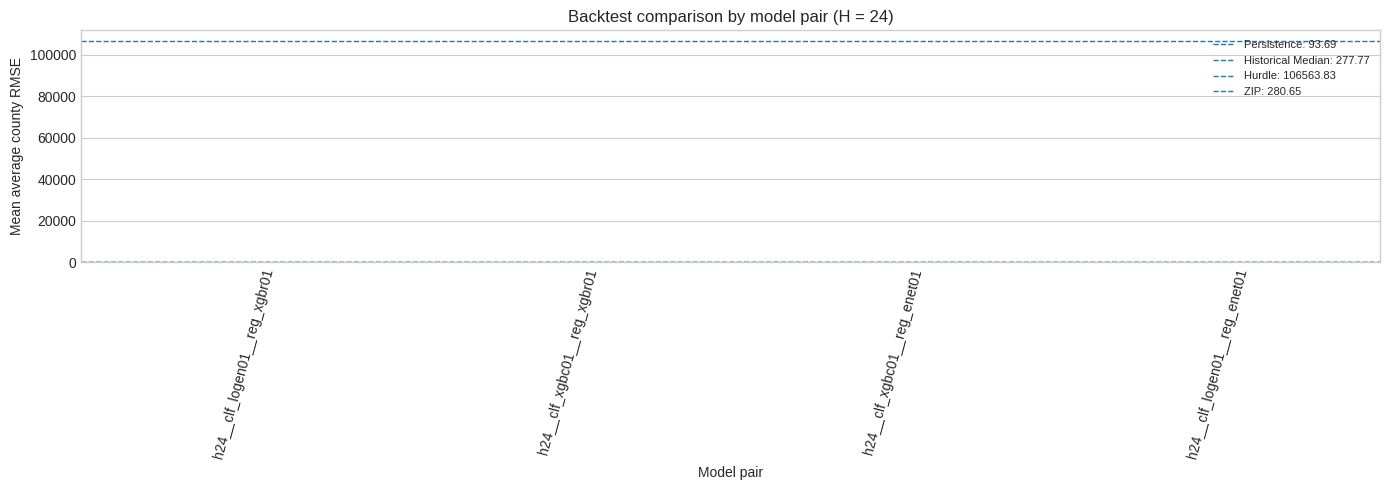

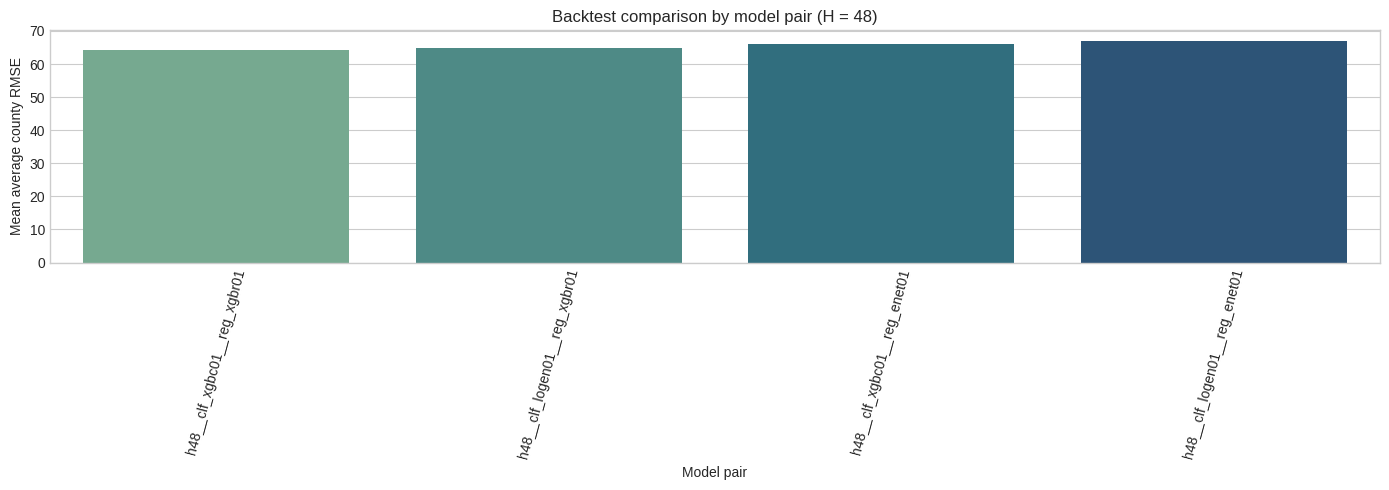

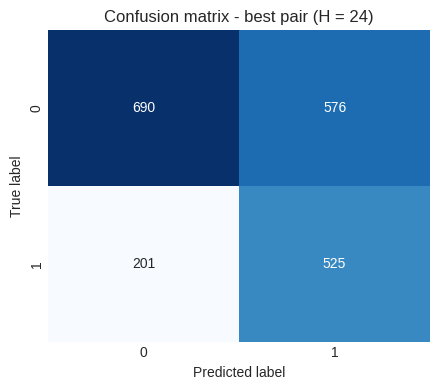

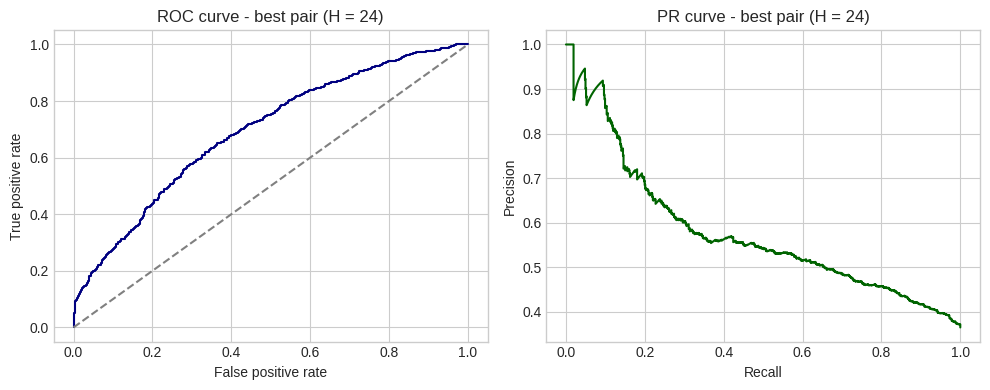

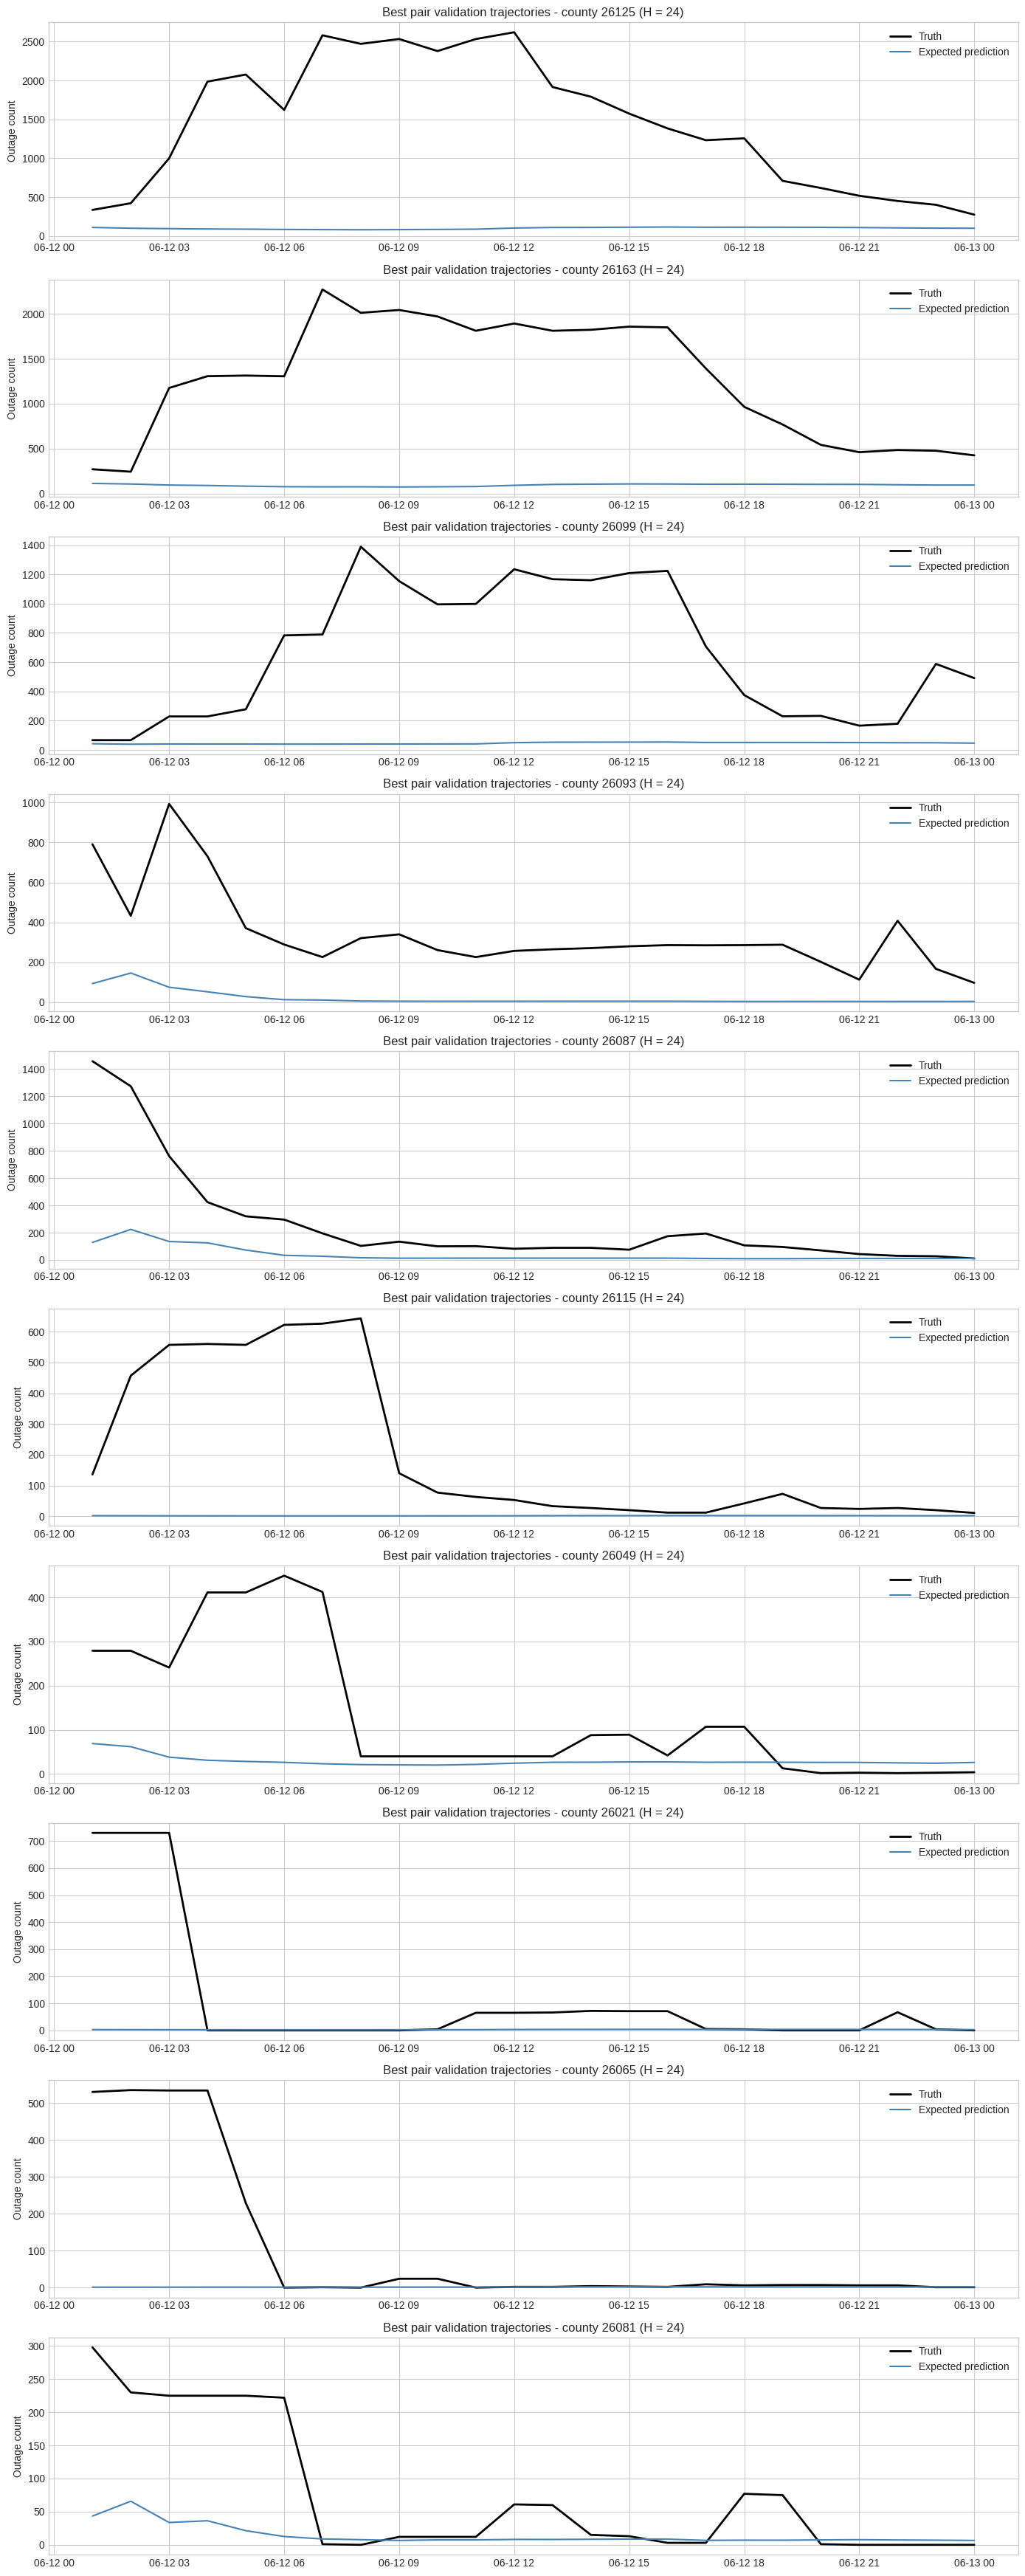

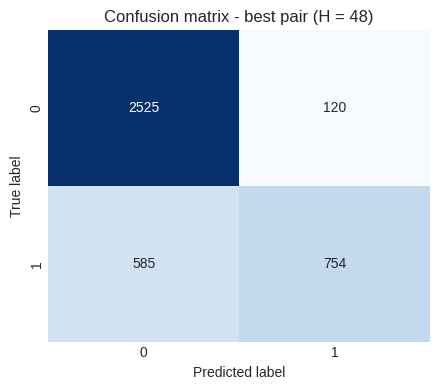

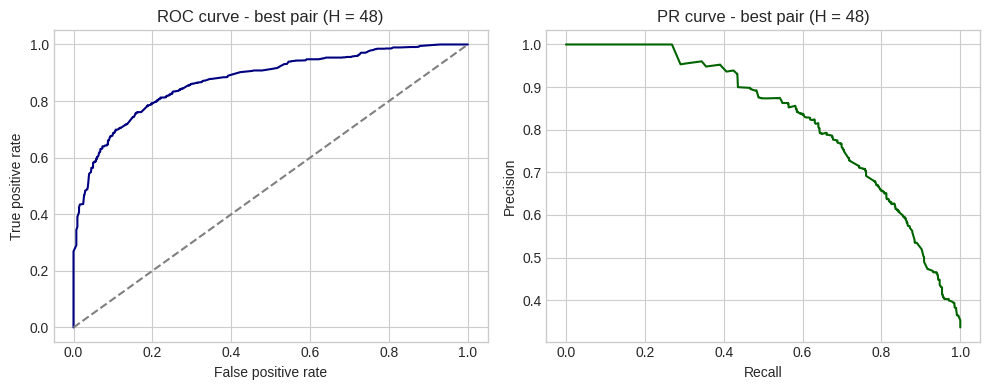

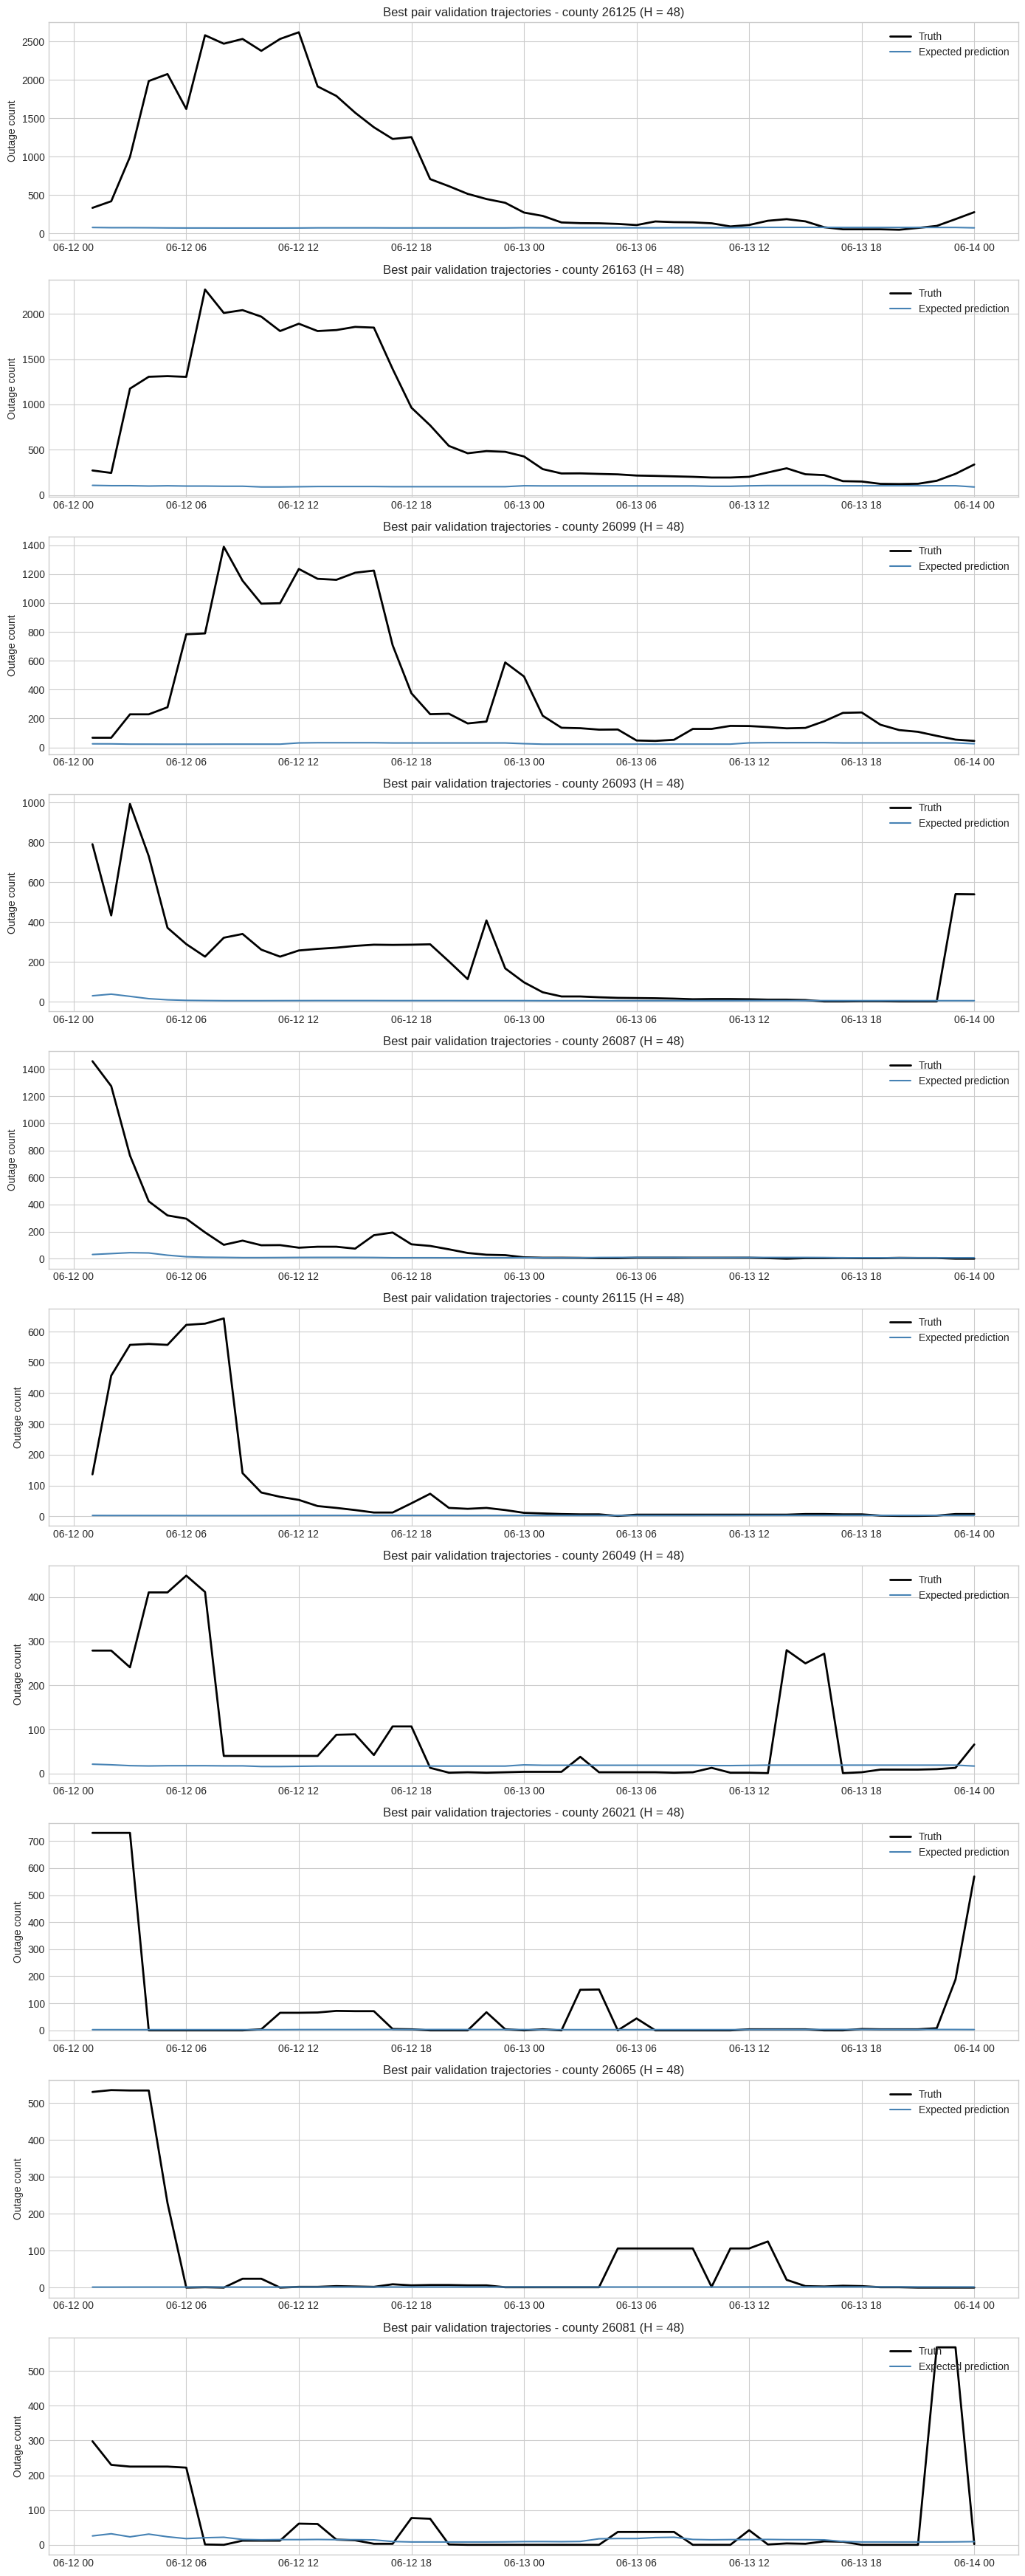

In [15]:
classifier_stage_summary = (
    pair_summary_df[
        [
            'horizon',
            'classifier_name',
            'classifier_params',
            'mean_stage1_roc_auc',
            'mean_stage1_average_precision',
            'mean_stage1_brier_score',
            'mean_stage1_f1',
        ]
    ]
    .drop_duplicates()
    .sort_values(['horizon', 'mean_stage1_average_precision'], ascending=[True, False])
    .reset_index(drop=True)
)
save_dataframe(classifier_stage_summary, ARTIFACT_DIRS['tables'] / 'classifier_stage_summary.csv', index=False)

regressor_stage_summary = (
    pair_summary_df[
        [
            'horizon',
            'regressor_name',
            'regressor_params',
            'mean_stage2_positive_rmse',
            'mean_stage2_positive_mae',
            'mean_stage2_positive_rows_train',
        ]
    ]
    .drop_duplicates()
    .sort_values(['horizon', 'mean_stage2_positive_rmse'], ascending=[True, True])
    .reset_index(drop=True)
)
save_dataframe(regressor_stage_summary, ARTIFACT_DIRS['tables'] / 'regressor_stage_summary.csv', index=False)

display(classifier_stage_summary)
display(regressor_stage_summary)

for horizon in config['horizons']:
    horizon_df = pair_summary_df.loc[pair_summary_df['horizon'] == horizon].copy()
    fig, ax = plt.subplots(figsize=(14, 5))
    sns.barplot(data=horizon_df, x='pair_tag', y='mean_avg_county_rmse_expected', palette='crest', ax=ax)
    ax.set_title(f'Backtest comparison by model pair (H = {horizon})')
    ax.set_ylabel('Mean average county RMSE')
    ax.set_xlabel('Model pair')
    ax.tick_params(axis='x', rotation=75)

    if horizon == 24:
        for baseline_name, baseline_value in BASELINE_24H_REFERENCE.items():
            ax.axhline(baseline_value, linestyle='--', linewidth=1.0, label=f'{baseline_name}: {baseline_value:.2f}')
        ax.legend(loc='upper right', fontsize=8)

    plt.tight_layout()
    plt.savefig(ARTIFACT_DIRS['plots'] / f'pair_comparison_h{horizon}.png', dpi=140)
    plt.show()

best_pair_lookup = {int(row['horizon']): row.to_dict() for _, row in best_pair_by_horizon.iterrows()}

for horizon, best_row in best_pair_lookup.items():
    best_predictions = []
    best_pair_tag = best_row['pair_tag']

    for pair_result in all_pair_results:
        if pair_result['pair_tag'] == best_pair_tag:
            for prediction_path in pair_result['fold_prediction_paths']:
                best_predictions.append(pd.read_csv(prediction_path))
            best_pair_paths = get_pair_artifact_paths(best_pair_tag)
            if len(pair_result['stage1_feature_signals']):
                save_dataframe(pair_result['stage1_feature_signals'], best_pair_paths['stage1_feature_signal'], index=False)
            if len(pair_result['stage2_feature_signals']):
                save_dataframe(pair_result['stage2_feature_signals'], best_pair_paths['stage2_feature_signal'], index=False)
            break

    if best_predictions:
        best_pred_df = pd.concat(best_predictions, ignore_index=True)
        confusion = confusion_matrix(
            best_pred_df['target_nonzero'].astype(int).values,
            (best_pred_df['stage1_proba'].values >= config['classifier_threshold']).astype(int),
            labels=[0, 1],
        )

        fig, ax = plt.subplots(figsize=(4.5, 4))
        sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
        ax.set_title(f'Confusion matrix - best pair (H = {horizon})')
        ax.set_xlabel('Predicted label')
        ax.set_ylabel('True label')
        plt.tight_layout()
        plt.savefig(ARTIFACT_DIRS['plots'] / f'best_pair_confusion_h{horizon}.png', dpi=140)
        plt.show()

        roc_auc = safe_auc(best_pred_df['target_nonzero'].astype(int).values, best_pred_df['stage1_proba'].values)
        if not np.isnan(roc_auc):
            fpr, tpr, _ = roc_curve(best_pred_df['target_nonzero'].astype(int).values, best_pred_df['stage1_proba'].values)
            precision, recall, _ = precision_recall_curve(best_pred_df['target_nonzero'].astype(int).values, best_pred_df['stage1_proba'].values)

            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            axes[0].plot(fpr, tpr, color='navy')
            axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
            axes[0].set_title(f'ROC curve - best pair (H = {horizon})')
            axes[0].set_xlabel('False positive rate')
            axes[0].set_ylabel('True positive rate')

            axes[1].plot(recall, precision, color='darkgreen')
            axes[1].set_title(f'PR curve - best pair (H = {horizon})')
            axes[1].set_xlabel('Recall')
            axes[1].set_ylabel('Precision')

            plt.tight_layout()
            plt.savefig(ARTIFACT_DIRS['plots'] / f'best_pair_curves_h{horizon}.png', dpi=140)
            plt.show()

        mean_truth = (
            best_pred_df.groupby(['location'])['target_out']
            .mean()
            .sort_values(ascending=False)
            .head(config['plot_top_k_counties'])
            .index.tolist()
        )

        plot_df = best_pred_df.loc[best_pred_df['location'].isin(mean_truth)].copy()
        plot_df = plot_df.sort_values(['location', 'target_timestamp'])

        fig, axes = plt.subplots(len(mean_truth), 1, figsize=(14, 3.5 * len(mean_truth)), sharex=False)
        if len(mean_truth) == 1:
            axes = [axes]

        for ax, location in zip(axes, mean_truth):
            subset = plot_df.loc[plot_df['location'] == location].copy()
            ax.plot(pd.to_datetime(subset['target_timestamp']), subset['target_out'], label='Truth', color='black', linewidth=2)
            ax.plot(pd.to_datetime(subset['target_timestamp']), subset['final_pred'], label='Expected prediction', color='steelblue', linewidth=1.5)
            ax.set_title(f'Best pair validation trajectories - county {location} (H = {horizon})')
            ax.set_ylabel('Outage count')
            ax.legend(loc='upper right')

        plt.tight_layout()
        plt.savefig(ARTIFACT_DIRS['plots'] / f'best_pair_validation_trajectories_h{horizon}.png', dpi=140)
        plt.show()


## Final training and submission-file generation

Once the best pair is selected for each horizon, we retrain on the **full available training history** (subject to the direct-forecast target availability constraint) and generate:

- saved model artifacts
- saved preprocessors
- demo evaluation predictions
- submission CSVs aligned to the official templates

### Important deployment detail

At inference time:

- we use the **latest observed county-hour** from `train.nc` as the forecast origin
- we do **not** use future weather
- target timestamp features come from the submission templates themselves

This keeps the final workflow aligned with the project rules.


In [16]:
def parse_submission_template(template_df: pd.DataFrame) -> pd.DataFrame:
    parsed = template_df.copy()
    parsed['location'] = parsed['location'].astype(str)
    parsed['timestamp'] = pd.to_datetime(parsed['timestamp'])
    parsed['row_id'] = np.arange(len(parsed))
    return parsed


template_24_parsed = parse_submission_template(template_24)
template_48_parsed = parse_submission_template(template_48)


def build_inference_dataset(base_df: pd.DataFrame, origin_idx: int, template_df: pd.DataFrame) -> pd.DataFrame:
    origin_rows = (
        base_df.loc[base_df['global_time_idx'] == origin_idx, ['location', 'timestamp'] + base_numeric_feature_cols]
        .copy()
        .rename(columns={'timestamp': 'origin_timestamp'})
    )
    # Do not drop end-of-series origins: any remaining numeric gaps are handled by the fitted zero-fill preprocessing pipeline at scoring time.

    inference_df = template_df.copy().rename(columns={'timestamp': 'target_timestamp'}).merge(origin_rows, on='location', how='left')
    last_train_timestamp = pd.Timestamp(all_timestamps[origin_idx])
    inference_df['horizon_step'] = ((pd.to_datetime(inference_df['target_timestamp']) - last_train_timestamp) / pd.Timedelta(hours=1)).astype(int)
    inference_df = add_target_time_features(inference_df)
    return inference_df.sort_values('row_id').reset_index(drop=True)


def fit_final_models_for_horizon(horizon: int, classifier_name: str, classifier_params: dict, regressor_name: str, regressor_params: dict):
    manual_split = config.get('manual_backtest_splits', {}).get(horizon)
    if manual_split is not None:
        val_origin_timestamp = pd.Timestamp(manual_split['val_origin_timestamp'])
        train_origin_start_timestamp = pd.Timestamp(manual_split['train_origin_start'])
        final_train_origin_max_idx = int(all_timestamps.get_loc(val_origin_timestamp)) - horizon
        final_train_start_idx = max(feature_warmup, int(all_timestamps.get_loc(train_origin_start_timestamp)))
    else:
        final_train_origin_max_idx = len(all_timestamps) - horizon - 1
        final_train_start_idx = max(
            feature_warmup,
            final_train_origin_max_idx - config['max_train_hours'] + 1,
        )
    final_train_origin_indices = list(range(final_train_start_idx, final_train_origin_max_idx + 1, config['origin_stride_hours']))
    final_train_df = build_stacked_dataset(model_df, final_train_origin_indices, horizon)
    validation_sample = final_train_df.sample(min(len(final_train_df), max(2000, horizon * len(locations))), random_state=config['seed'])

    stage1_result = fit_stage1_classifier(final_train_df, validation_sample, classifier_name, classifier_params)
    stage2_result = fit_stage2_regressor(final_train_df, validation_sample, regressor_name, regressor_params)

    bundle = {
        'horizon': horizon,
        'classifier_name': classifier_name,
        'classifier_params': classifier_params,
        'regressor_name': regressor_name,
        'regressor_params': regressor_params,
        'stage1': {
            'preprocessor': stage1_result['preprocessor'],
            'model': stage1_result['model'],
            'feature_names': stage1_result['feature_names'],
            'history': stage1_result['history'],
        },
        'stage2': {
            'preprocessor': stage2_result['preprocessor'],
            'model': stage2_result['model'],
            'feature_names': stage2_result['feature_names'],
            'history': stage2_result['history'],
            'fallback_value_log1p': stage2_result['fallback_value_log1p'],
        },
        'final_train_origin_indices': final_train_origin_indices,
        'final_train_origin_max_idx': int(final_train_origin_max_idx),
        'final_train_origin_max_timestamp': pd.Timestamp(all_timestamps[final_train_origin_max_idx]),
    }
    return bundle


def predict_with_final_bundle(bundle: dict, inference_df: pd.DataFrame) -> pd.DataFrame:
    numeric_cols = base_numeric_feature_cols + dynamic_numeric_feature_cols
    categorical_cols = categorical_feature_cols
    feature_view = inference_df[numeric_cols + categorical_cols].copy()

    # Score every row and let the fitted zero-fill preprocessing pipeline handle any raw numeric gaps.
    raw_feature_complete = feature_view[numeric_cols].notna().all(axis=1)

    stage1_preprocessor = bundle['stage1']['preprocessor']
    stage1_model = bundle['stage1']['model']
    X_stage1 = stage1_preprocessor.transform(feature_view)
    stage1_proba = stage1_model.predict_proba(X_stage1)[:, 1]

    stage2_preprocessor = bundle['stage2']['preprocessor']
    stage2_model = bundle['stage2']['model']

    if stage2_model is None or stage2_preprocessor is None:
        positive_pred = np.expm1(
            np.full(len(inference_df), bundle['stage2']['fallback_value_log1p'])
        )
    else:
        X_stage2 = stage2_preprocessor.transform(feature_view)
        positive_pred = np.expm1(stage2_model.predict(X_stage2))

    positive_pred = np.clip(positive_pred, 0.0, None)

    prediction_df = inference_df.copy()
    prediction_df['raw_feature_complete'] = raw_feature_complete.astype(int)
    prediction_df['prediction_ready'] = 1
    prediction_df['stage1_proba'] = stage1_proba
    prediction_df['stage2_positive_pred'] = positive_pred
    prediction_df['pred'] = prediction_df['stage1_proba'] * prediction_df['stage2_positive_pred']
    prediction_df['pred'] = prediction_df['pred'].fillna(0.0)
    return prediction_df


def build_final_refit_paths(horizon: int) -> dict:
    return {
        'two_stage': ARTIFACT_DIRS['models'] / f'final_bundle_h{horizon}.joblib',
        'stage1': ARTIFACT_DIRS['models'] / f'final_stage1_h{horizon}_classifier.joblib',
        'stage2': ARTIFACT_DIRS['models'] / f'final_stage2_h{horizon}_regressor.joblib',
        'metadata': ARTIFACT_DIRS['models'] / f'final_bundle_h{horizon}_metadata.json',
        'prediction': ARTIFACT_DIRS['predictions'] / f'final_refit_pred_{horizon}h.csv',
    }


def build_submission_model_paths(horizon: int) -> dict:
    return {
        'two_stage': ARTIFACT_DIRS['models'] / f'submission_bundle_h{horizon}.joblib',
        'stage1': ARTIFACT_DIRS['models'] / f'submission_stage1_h{horizon}_classifier.joblib',
        'stage2': ARTIFACT_DIRS['models'] / f'submission_stage2_h{horizon}_regressor.joblib',
        'metadata': ARTIFACT_DIRS['models'] / f'submission_bundle_h{horizon}_metadata.json',
    }


def is_reusable_stage1_artifact(path: Path) -> bool:
    payload = load_joblib_artifact(path)
    return isinstance(payload, dict) and {'preprocessor', 'model', 'feature_names'}.issubset(payload.keys())


def is_reusable_stage2_artifact(path: Path) -> bool:
    payload = load_joblib_artifact(path)
    return isinstance(payload, dict) and {'preprocessor', 'feature_names', 'fallback_value_log1p'}.issubset(payload.keys())


def is_reusable_two_stage_bundle(bundle) -> bool:
    return (
        isinstance(bundle, dict)
        and isinstance(bundle.get('stage1'), dict)
        and isinstance(bundle.get('stage2'), dict)
        and {'preprocessor', 'model', 'feature_names'}.issubset(bundle['stage1'].keys())
        and {'preprocessor', 'feature_names', 'fallback_value_log1p'}.issubset(bundle['stage2'].keys())
    )


def load_reusable_two_stage_bundle(path: Path):
    bundle = load_joblib_artifact(path)
    return bundle if is_reusable_two_stage_bundle(bundle) else None


def named_model_artifacts_complete(paths: dict) -> bool:
    return (
        load_reusable_two_stage_bundle(paths['two_stage']) is not None
        and is_reusable_stage1_artifact(paths['stage1'])
        and is_reusable_stage2_artifact(paths['stage2'])
    )


def build_serializable_two_stage_artifact(
    bundle: dict,
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    artifact_role: str,
    extra_metadata: dict | None = None,
) -> dict:
    artifact = {
        'artifact_role': artifact_role,
        'horizon': horizon,
        'classifier_name': classifier_name,
        'classifier_params': deepcopy(classifier_params),
        'regressor_name': regressor_name,
        'regressor_params': deepcopy(regressor_params),
        'stage1': {
            'preprocessor': bundle['stage1']['preprocessor'],
            'model': bundle['stage1']['model'],
            'feature_names': deepcopy(bundle['stage1'].get('feature_names', [])),
            'history': deepcopy(bundle['stage1'].get('history', {})),
        },
        'stage2': {
            'preprocessor': bundle['stage2']['preprocessor'],
            'model': bundle['stage2']['model'],
            'feature_names': deepcopy(bundle['stage2'].get('feature_names', [])),
            'history': deepcopy(bundle['stage2'].get('history', {})),
            'fallback_value_log1p': bundle['stage2']['fallback_value_log1p'],
        },
        'final_train_origin_indices': deepcopy(bundle.get('final_train_origin_indices', [])),
        'final_train_origin_max_idx': bundle.get('final_train_origin_max_idx'),
        'final_train_origin_max_timestamp': bundle.get('final_train_origin_max_timestamp'),
    }
    if extra_metadata:
        artifact.update(deepcopy(extra_metadata))
    return artifact


def build_serializable_stage1_artifact(
    bundle: dict,
    horizon: int,
    model_name: str,
    model_params: dict,
    artifact_role: str,
    extra_metadata: dict | None = None,
) -> dict:
    artifact = {
        'artifact_role': artifact_role,
        'horizon': horizon,
        'model_name': model_name,
        'model_params': deepcopy(model_params),
        'preprocessor': bundle['stage1']['preprocessor'],
        'model': bundle['stage1']['model'],
        'feature_names': deepcopy(bundle['stage1'].get('feature_names', [])),
        'history': deepcopy(bundle['stage1'].get('history', {})),
    }
    if extra_metadata:
        artifact.update(deepcopy(extra_metadata))
    return artifact


def build_serializable_stage2_artifact(
    bundle: dict,
    horizon: int,
    model_name: str,
    model_params: dict,
    artifact_role: str,
    extra_metadata: dict | None = None,
) -> dict:
    artifact = {
        'artifact_role': artifact_role,
        'horizon': horizon,
        'model_name': model_name,
        'model_params': deepcopy(model_params),
        'preprocessor': bundle['stage2']['preprocessor'],
        'model': bundle['stage2']['model'],
        'feature_names': deepcopy(bundle['stage2'].get('feature_names', [])),
        'history': deepcopy(bundle['stage2'].get('history', {})),
        'fallback_value_log1p': bundle['stage2']['fallback_value_log1p'],
    }
    if extra_metadata:
        artifact.update(deepcopy(extra_metadata))
    return artifact


def save_named_model_triplet(
    bundle: dict,
    horizon: int,
    classifier_name: str,
    classifier_params: dict,
    regressor_name: str,
    regressor_params: dict,
    artifact_paths: dict,
    artifact_role_prefix: str,
    metadata_payload: dict,
    extra_metadata: dict | None = None,
    allow_reuse_existing: bool = False,
):
    if allow_reuse_existing and named_model_artifacts_complete(artifact_paths) and is_valid_json_artifact(artifact_paths['metadata']):
        return

    joblib.dump(
        build_serializable_two_stage_artifact(
            bundle=bundle,
            horizon=horizon,
            classifier_name=classifier_name,
            classifier_params=classifier_params,
            regressor_name=regressor_name,
            regressor_params=regressor_params,
            artifact_role=f'{artifact_role_prefix}_two_stage',
            extra_metadata=extra_metadata,
        ),
        artifact_paths['two_stage'],
        compress=3,
    )
    joblib.dump(
        build_serializable_stage1_artifact(
            bundle=bundle,
            horizon=horizon,
            model_name=classifier_name,
            model_params=classifier_params,
            artifact_role=f'{artifact_role_prefix}_stage1_classifier',
            extra_metadata=extra_metadata,
        ),
        artifact_paths['stage1'],
        compress=3,
    )
    joblib.dump(
        build_serializable_stage2_artifact(
            bundle=bundle,
            horizon=horizon,
            model_name=regressor_name,
            model_params=regressor_params,
            artifact_role=f'{artifact_role_prefix}_stage2_regressor',
            extra_metadata=extra_metadata,
        ),
        artifact_paths['stage2'],
        compress=3,
    )
    save_json(metadata_payload, artifact_paths['metadata'])


def fit_or_load_final_refit_bundle(horizon: int, classifier_name: str, classifier_params: dict, regressor_name: str, regressor_params: dict):
    final_paths = build_final_refit_paths(horizon)
    if config.get('reuse_existing_final_refit_artifacts', True):
        existing_bundle = load_reusable_two_stage_bundle(final_paths['two_stage'])
        if existing_bundle is not None:
            return existing_bundle, 'reused_existing_refit'
    return fit_final_models_for_horizon(horizon, classifier_name, classifier_params, regressor_name, regressor_params), 'trained_refit'


def resolve_candidate_bundle_path(candidate_row: dict) -> Path:
    path_value = candidate_row.get('two_stage_model_path')
    if isinstance(path_value, str) and path_value.strip():
        candidate_path = PROJECT_ROOT / path_value
        if candidate_path.exists():
            return candidate_path
    return get_pair_artifact_paths(candidate_row['pair_tag'], fold_id=int(candidate_row['fold_id']))['two_stage_model']


def load_submission_bundle_for_horizon(horizon: int, candidate_row: dict, fallback_bundle: dict):
    submission_paths = build_submission_model_paths(horizon)
    classifier_name = candidate_row.get('classifier_name')
    classifier_params = json.loads(candidate_row.get('classifier_params', '{}'))
    regressor_name = candidate_row.get('regressor_name')
    regressor_params = json.loads(candidate_row.get('regressor_params', '{}'))

    metadata_payload = {
        'horizon': horizon,
        'selection_source': 'best_candidate_validation_model',
        'source_pair_tag': candidate_row['pair_tag'],
        'source_fold_id': int(candidate_row['fold_id']),
        'classifier_name': classifier_name,
        'classifier_params': classifier_params,
        'regressor_name': regressor_name,
        'regressor_params': regressor_params,
        'avg_county_rmse_expected': candidate_row.get('avg_county_rmse_expected'),
        'overall_rmse_expected': candidate_row.get('overall_rmse_expected'),
    }
    extra_metadata = {
        'source_pair_tag': candidate_row['pair_tag'],
        'source_fold_id': int(candidate_row['fold_id']),
        'selection_source': 'best_candidate_validation_model',
    }

    if config.get('reuse_existing_submission_model_artifacts', True):
        existing_submission_bundle = load_reusable_two_stage_bundle(submission_paths['two_stage'])
        if existing_submission_bundle is not None:
            if config.get('save_submission_model_copies', True):
                save_named_model_triplet(
                    bundle=existing_submission_bundle,
                    horizon=horizon,
                    classifier_name=classifier_name,
                    classifier_params=classifier_params,
                    regressor_name=regressor_name,
                    regressor_params=regressor_params,
                    artifact_paths=submission_paths,
                    artifact_role_prefix='selected_submission',
                    metadata_payload=metadata_payload,
                    extra_metadata=extra_metadata,
                    allow_reuse_existing=config.get('reuse_existing_submission_model_artifacts', True),
                )
            return existing_submission_bundle, submission_paths, 'reused_submission_copy'

    candidate_path = resolve_candidate_bundle_path(candidate_row)
    candidate_bundle = load_reusable_two_stage_bundle(candidate_path)
    if candidate_bundle is None:
        print(f'H={horizon}: submission candidate bundle was not reusable at {candidate_path.name}. Falling back to the final refit bundle.')
        return fallback_bundle, submission_paths, 'final_refit_fallback'

    if config.get('save_submission_model_copies', True):
        save_named_model_triplet(
            bundle=candidate_bundle,
            horizon=horizon,
            classifier_name=classifier_name,
            classifier_params=classifier_params,
            regressor_name=regressor_name,
            regressor_params=regressor_params,
            artifact_paths=submission_paths,
            artifact_role_prefix='selected_submission',
            metadata_payload=metadata_payload,
            extra_metadata=extra_metadata,
            allow_reuse_existing=config.get('reuse_existing_submission_model_artifacts', True),
        )

    return candidate_bundle, submission_paths, 'best_candidate_validation_model'


def build_submission_frame(template_df: pd.DataFrame, prediction_df: pd.DataFrame) -> pd.DataFrame:
    submission_df = template_df.copy()
    submission_df['pred'] = prediction_df.sort_values('row_id')['pred'].fillna(0.0).values
    return submission_df[['timestamp', 'location', 'pred']]


def evaluate_submission_against_demo(submission_df: pd.DataFrame, horizon: int):
    dataset = ds_test_24h if horizon == 24 else ds_test_48h
    if dataset is None:
        return None

    demo_truth_df = (
        dataset.out
        .to_dataframe(name='target_out')
        .reset_index()
        .assign(location=lambda df: df['location'].astype(str), timestamp=lambda df: pd.to_datetime(df['timestamp']))
    )
    demo_eval_df = submission_df.merge(demo_truth_df, on=['timestamp', 'location'], how='inner')
    if not len(demo_eval_df):
        return None

    return {
        'overall_rmse': rmse(demo_eval_df['target_out'].values, demo_eval_df['pred'].values),
        'overall_mae': float(mean_absolute_error(demo_eval_df['target_out'].values, demo_eval_df['pred'].values)),
        'avg_county_rmse': average_county_rmse(demo_eval_df, 'pred'),
        'n_rows': int(len(demo_eval_df)),
        'n_locations': int(demo_eval_df['location'].nunique()),
    }


best_candidate_model_lookup = {int(row['horizon']): row.to_dict() for _, row in best_candidate_model_by_horizon.iterrows()}

final_model_registry = {}
submission_model_registry = {}
final_refit_paths_lookup = {}
submission_model_paths_lookup = {}
submission_model_lookup = {}
final_refit_summary_rows = []
submission_model_summary_rows = []

for horizon, best_row in best_pair_lookup.items():
    classifier_name = best_row['classifier_name']
    classifier_params = json.loads(best_row['classifier_params'])
    regressor_name = best_row['regressor_name']
    regressor_params = json.loads(best_row['regressor_params'])

    final_paths = build_final_refit_paths(horizon)
    final_bundle, final_bundle_source = fit_or_load_final_refit_bundle(
        horizon,
        classifier_name,
        classifier_params,
        regressor_name,
        regressor_params,
    )
    final_model_registry[horizon] = final_bundle
    final_refit_paths_lookup[horizon] = final_paths

    final_refit_metadata = {
        'horizon': horizon,
        'selection_source': 'best_pair_by_horizon',
        'source_pair_tag': best_row['pair_tag'],
        'classifier_name': classifier_name,
        'classifier_params': classifier_params,
        'regressor_name': regressor_name,
        'regressor_params': regressor_params,
        'bundle_source': final_bundle_source,
        'final_train_origin_max_timestamp': final_bundle['final_train_origin_max_timestamp'],
        'source_validation_metrics': {key: best_row[key] for key in best_row.keys() if str(key).startswith('mean_')},
    }
    final_refit_extra_metadata = {
        'source_pair_tag': best_row['pair_tag'],
        'selection_source': 'best_pair_by_horizon',
    }

    save_named_model_triplet(
        bundle=final_bundle,
        horizon=horizon,
        classifier_name=classifier_name,
        classifier_params=classifier_params,
        regressor_name=regressor_name,
        regressor_params=regressor_params,
        artifact_paths=final_paths,
        artifact_role_prefix='final_refit',
        metadata_payload=final_refit_metadata,
        extra_metadata=final_refit_extra_metadata,
        allow_reuse_existing=config.get('reuse_existing_final_refit_artifacts', True),
    )

    refit_summary_row = {
        'horizon': horizon,
        'pair_tag': best_row['pair_tag'],
        'classifier_name': classifier_name,
        'classifier_params': json.dumps(classifier_params, default=json_default),
        'regressor_name': regressor_name,
        'regressor_params': json.dumps(regressor_params, default=json_default),
        'bundle_source': final_bundle_source,
        'refit_two_stage_model_path': project_relative_artifact_path(final_paths['two_stage']),
        'refit_stage1_model_path': project_relative_artifact_path(final_paths['stage1']),
        'refit_stage2_model_path': project_relative_artifact_path(final_paths['stage2']),
        'refit_prediction_path': project_relative_artifact_path(final_paths['prediction']),
    }
    for key, value in best_row.items():
        if str(key).startswith('mean_'):
            refit_summary_row[key] = value
    final_refit_summary_rows.append(refit_summary_row)

    submission_source = config.get('prediction_model_source', 'best_candidate_validation_model')
    submission_paths = build_submission_model_paths(horizon)
    selected_candidate_row = best_candidate_model_lookup.get(horizon)
    if submission_source == 'best_candidate_validation_model' and selected_candidate_row is not None:
        submission_bundle, submission_paths, submission_bundle_source = load_submission_bundle_for_horizon(
            horizon=horizon,
            candidate_row=selected_candidate_row,
            fallback_bundle=final_bundle,
        )
        submission_row = {
            'horizon': horizon,
            'prediction_model_source': submission_source,
            'bundle_source': submission_bundle_source,
            'pair_tag': selected_candidate_row['pair_tag'],
            'fold_id': int(selected_candidate_row['fold_id']),
            'classifier_name': selected_candidate_row['classifier_name'],
            'classifier_params': selected_candidate_row['classifier_params'],
            'regressor_name': selected_candidate_row['regressor_name'],
            'regressor_params': selected_candidate_row['regressor_params'],
            'submission_two_stage_model_path': project_relative_artifact_path(submission_paths['two_stage']),
            'submission_stage1_model_path': project_relative_artifact_path(submission_paths['stage1']),
            'submission_stage2_model_path': project_relative_artifact_path(submission_paths['stage2']),
            'source_candidate_two_stage_model_path': project_relative_artifact_path(resolve_candidate_bundle_path(selected_candidate_row)),
        }
        for key in selected_candidate_row.keys():
            if key not in submission_row:
                submission_row[key] = selected_candidate_row[key]
        submission_model_lookup[horizon] = {
            'source': submission_bundle_source,
            'pair_tag': selected_candidate_row['pair_tag'],
            'fold_id': int(selected_candidate_row['fold_id']),
        }
    else:
        submission_bundle = final_bundle
        submission_bundle_source = 'final_refit'
        submission_model_lookup[horizon] = {
            'source': submission_bundle_source,
            'pair_tag': best_row['pair_tag'],
            'fold_id': np.nan,
        }
        if config.get('save_submission_model_copies', True):
            fallback_submission_metadata = {
                'horizon': horizon,
                'selection_source': 'final_refit',
                'source_pair_tag': best_row['pair_tag'],
                'classifier_name': classifier_name,
                'classifier_params': classifier_params,
                'regressor_name': regressor_name,
                'regressor_params': regressor_params,
                'bundle_source': submission_bundle_source,
            }
            fallback_submission_extra = {
                'source_pair_tag': best_row['pair_tag'],
                'selection_source': 'final_refit',
            }
            save_named_model_triplet(
                bundle=submission_bundle,
                horizon=horizon,
                classifier_name=classifier_name,
                classifier_params=classifier_params,
                regressor_name=regressor_name,
                regressor_params=regressor_params,
                artifact_paths=submission_paths,
                artifact_role_prefix='selected_submission',
                metadata_payload=fallback_submission_metadata,
                extra_metadata=fallback_submission_extra,
                allow_reuse_existing=config.get('reuse_existing_submission_model_artifacts', True),
            )

        submission_row = {
            'horizon': horizon,
            'prediction_model_source': 'final_refit',
            'bundle_source': submission_bundle_source,
            'pair_tag': best_row['pair_tag'],
            'fold_id': np.nan,
            'classifier_name': classifier_name,
            'classifier_params': json.dumps(classifier_params, default=json_default),
            'regressor_name': regressor_name,
            'regressor_params': json.dumps(regressor_params, default=json_default),
            'submission_two_stage_model_path': project_relative_artifact_path(submission_paths['two_stage']),
            'submission_stage1_model_path': project_relative_artifact_path(submission_paths['stage1']),
            'submission_stage2_model_path': project_relative_artifact_path(submission_paths['stage2']),
            'source_candidate_two_stage_model_path': np.nan,
        }
        for key, value in best_row.items():
            if str(key).startswith('mean_'):
                submission_row[f'source_{key}'] = value

    submission_model_registry[horizon] = submission_bundle
    submission_model_paths_lookup[horizon] = submission_paths
    submission_model_summary_rows.append(submission_row)

final_refit_validation_summary_df = pd.DataFrame(final_refit_summary_rows).sort_values('horizon').reset_index(drop=True)
submission_model_summary_df = pd.DataFrame(submission_model_summary_rows).sort_values('horizon').reset_index(drop=True)

save_dataframe(final_refit_validation_summary_df, ARTIFACT_DIRS['tables'] / 'final_refit_validation_summary.csv', index=False)
save_dataframe(submission_model_summary_df, ARTIFACT_DIRS['tables'] / 'submission_model_summary.csv', index=False)

display(final_refit_validation_summary_df)
display(submission_model_summary_df)

# Reused submission-file convention from the starter/demo notebooks:
# final predictions are aligned to the official 24h and 48h templates.
inference_by_horizon = {
    24: build_inference_dataset(model_df, origin_idx=len(all_timestamps) - 1, template_df=template_24_parsed),
    48: build_inference_dataset(model_df, origin_idx=len(all_timestamps) - 1, template_df=template_48_parsed),
}

submission_predictions = {}
final_refit_predictions = {}

for horizon, inference_df in inference_by_horizon.items():
    submission_pred = predict_with_final_bundle(submission_model_registry[horizon], inference_df)
    refit_pred = predict_with_final_bundle(final_model_registry[horizon], inference_df)
    submission_predictions[horizon] = submission_pred
    final_refit_predictions[horizon] = refit_pred

    raw_incomplete_submission_rows = int((submission_pred['raw_feature_complete'] == 0).sum())
    raw_incomplete_refit_rows = int((refit_pred['raw_feature_complete'] == 0).sum())
    if raw_incomplete_submission_rows:
        print(f'{horizon}h submission rows with incomplete raw inference features: {raw_incomplete_submission_rows}. They were still scored using the fitted zero-fill preprocessing pipeline.')
    if raw_incomplete_refit_rows:
        print(f'{horizon}h refit rows with incomplete raw inference features: {raw_incomplete_refit_rows}. They were still scored using the fitted zero-fill preprocessing pipeline.')

submission_24 = build_submission_frame(template_24_parsed, submission_predictions[24])
submission_48 = build_submission_frame(template_48_parsed, submission_predictions[48])
final_refit_submission_24 = build_submission_frame(template_24_parsed, final_refit_predictions[24])
final_refit_submission_48 = build_submission_frame(template_48_parsed, final_refit_predictions[48])

save_dataframe(submission_24, ARTIFACT_DIRS['predictions'] / 'two_stage_pred_24h.csv', index=False)
save_dataframe(submission_48, ARTIFACT_DIRS['predictions'] / 'two_stage_pred_48h.csv', index=False)
save_dataframe(final_refit_submission_24, final_refit_paths_lookup[24]['prediction'], index=False)
save_dataframe(final_refit_submission_48, final_refit_paths_lookup[48]['prediction'], index=False)

display(submission_24.head())
display(submission_48.head())
display(final_refit_submission_24.head())
display(final_refit_submission_48.head())

if config['use_demo_evaluation']:
    submission_demo_24 = evaluate_submission_against_demo(submission_24, horizon=24)
    if submission_demo_24 is not None:
        save_json(submission_demo_24, ARTIFACT_DIRS['metrics'] / 'demo_eval_24h.json')
        print('Demo-only evaluation for 24h submission model:', submission_demo_24)

    submission_demo_48 = evaluate_submission_against_demo(submission_48, horizon=48)
    if submission_demo_48 is not None:
        save_json(submission_demo_48, ARTIFACT_DIRS['metrics'] / 'demo_eval_48h.json')
        print('Demo-only evaluation for 48h submission model:', submission_demo_48)

    refit_demo_24 = evaluate_submission_against_demo(final_refit_submission_24, horizon=24)
    if refit_demo_24 is not None:
        save_json(refit_demo_24, ARTIFACT_DIRS['metrics'] / 'demo_eval_final_refit_24h.json')
        print('Demo-only evaluation for 24h final refit:', refit_demo_24)

    refit_demo_48 = evaluate_submission_against_demo(final_refit_submission_48, horizon=48)
    if refit_demo_48 is not None:
        save_json(refit_demo_48, ARTIFACT_DIRS['metrics'] / 'demo_eval_final_refit_48h.json')
        print('Demo-only evaluation for 48h final refit:', refit_demo_48)


,horizon,pair_tag,classifier_name,classifier_params,regressor_name,regressor_params,bundle_source,refit_two_stage_model_path,refit_stage1_model_path,refit_stage2_model_path,refit_prediction_path,mean_horizon,mean_fold_id,mean_avg_county_rmse_expected,mean_avg_county_rmse_hard_gate,mean_overall_rmse_expected,mean_overall_mae_expected,mean_zero_baseline_rmse,mean_zero_baseline_avg_county_rmse,mean_stage1_roc_auc,mean_stage1_average_precision,mean_stage1_brier_score,mean_stage1_log_loss,mean_stage1_precision,mean_stage1_recall,mean_stage1_f1,mean_stage1_tn,mean_stage1_fp,mean_stage1_fn,mean_stage1_tp,mean_stage2_positive_rows_train,mean_stage2_positive_rows_valid,mean_stage2_positive_rmse,mean_stage2_positive_mae,mean_stage2_fallback_only
0,24,h24__clf_logen01__reg_xgbr01,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",trained_refit,results/run_20260419_061735/models/final_bundl...,results/run_20260419_061735/models/final_stage...,results/run_20260419_061735/models/final_stage...,results/run_20260419_061735/predictions/final_...,24.0,1.0,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690.0,576.0,201.0,525.0,140860.0,726.0,418.281960,153.843761,0.0
1,48,h48__clf_xgbc01__reg_xgbr01,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",trained_refit,results/run_20260419_061735/models/final_bundl...,results/run_20260419_061735/models/final_stage...,results/run_20260419_061735/models/final_stage...,results/run_20260419_061735/predictions/final_...,48.0,1.0,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525.0,120.0,585.0,754.0,252291.0,1339.0,318.720147,99.248179,0.0


,horizon,prediction_model_source,bundle_source,pair_tag,fold_id,classifier_name,classifier_params,regressor_name,regressor_params,submission_two_stage_model_path,submission_stage1_model_path,submission_stage2_model_path,source_candidate_two_stage_model_path,two_stage_model_path,stage1_model_path,stage2_model_path,avg_county_rmse_expected,avg_county_rmse_hard_gate,overall_rmse_expected,overall_mae_expected,zero_baseline_rmse,zero_baseline_avg_county_rmse,stage1_roc_auc,stage1_average_precision,stage1_brier_score,stage1_log_loss,stage1_precision,stage1_recall,stage1_f1,stage1_tn,stage1_fp,stage1_fn,stage1_tp,stage2_positive_rows_train,stage2_positive_rows_valid,stage2_positive_rmse,stage2_positive_mae,stage2_fallback_only
0,24,best_candidate_validation_model,best_candidate_validation_model,h24__clf_logen01__reg_xgbr01,1,logistic_enet,"{""C"": 0.5, ""l1_ratio"": 0.15, ""class_weight"": ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,results/run_20260419_061735/models/pair_h24__c...,82.088593,80.644165,258.332284,59.801566,273.353584,86.709700,0.691897,0.577728,0.233623,0.667390,0.476839,0.723140,0.574713,690,576,201,525,140860,726,418.281960,153.843761,False
1,48,best_candidate_validation_model,best_candidate_validation_model,h48__clf_xgbc01__reg_xgbr01,1,xgb_classifier,"{""n_estimators"": 150, ""learning_rate"": 0.08, ""...",xgb_regressor,"{""n_estimators"": 200, ""learning_rate"": 0.06, ""...",results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/submission_...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,results/run_20260419_061735/models/pair_h48__c...,64.343103,63.262862,187.724458,34.949639,196.730690,66.716768,0.873969,0.823744,0.137448,0.440271,0.862700,0.563107,0.681428,2525,120,585,754,252291,1339,318.720147,99.248179,False


24h submission rows with incomplete raw inference features: 1848. They were still scored using the fitted zero-fill preprocessing pipeline.
24h refit rows with incomplete raw inference features: 1848. They were still scored using the fitted zero-fill preprocessing pipeline.
48h submission rows with incomplete raw inference features: 3696. They were still scored using the fitted zero-fill preprocessing pipeline.
48h refit rows with incomplete raw inference features: 3696. They were still scored using the fitted zero-fill preprocessing pipeline.


,timestamp,location,pred
0,2023-06-30 01:00:00,26001,7.134867
1,2023-06-30 02:00:00,26001,7.729726
2,2023-06-30 03:00:00,26001,7.187766
3,2023-06-30 04:00:00,26001,13.091325
4,2023-06-30 05:00:00,26001,11.329362


,timestamp,location,pred
0,2023-06-30 01:00:00,26001,5.527732
1,2023-06-30 02:00:00,26001,4.654502
2,2023-06-30 03:00:00,26001,4.612779
3,2023-06-30 04:00:00,26001,5.505625
4,2023-06-30 05:00:00,26001,5.569728


,timestamp,location,pred
0,2023-06-30 01:00:00,26001,4.367264
1,2023-06-30 02:00:00,26001,4.391167
2,2023-06-30 03:00:00,26001,4.748393
3,2023-06-30 04:00:00,26001,8.575209
4,2023-06-30 05:00:00,26001,6.324484


,timestamp,location,pred
0,2023-06-30 01:00:00,26001,8.586742
1,2023-06-30 02:00:00,26001,2.711839
2,2023-06-30 03:00:00,26001,2.239507
3,2023-06-30 04:00:00,26001,3.365212
4,2023-06-30 05:00:00,26001,3.987714


Demo-only evaluation for 24h submission model: {'overall_rmse': 37.040407447862854, 'overall_mae': 9.760572571673864, 'avg_county_rmse': 10.617704949670141, 'n_rows': 1992, 'n_locations': 83}
Demo-only evaluation for 48h submission model: {'overall_rmse': 16.259926266062788, 'overall_mae': 5.2523717981838125, 'avg_county_rmse': 5.513506553233316, 'n_rows': 3984, 'n_locations': 83}
Demo-only evaluation for 24h final refit: {'overall_rmse': 46.83029263683949, 'overall_mae': 11.96582215672891, 'avg_county_rmse': 13.492210309601646, 'n_rows': 1992, 'n_locations': 83}
Demo-only evaluation for 48h final refit: {'overall_rmse': 27.745008664729067, 'overall_mae': 6.60366345304904, 'avg_county_rmse': 7.199990245046805, 'n_rows': 3984, 'n_locations': 83}


## Final model diagnostics

The available training-history diagnostics depend on the model family:

- for **XGBoost**, we have true boosting-round evaluation traces
- for **Elastic Net / Logistic Regression**, we mostly have convergence summaries and coefficient-based diagnostics

The plots below are meant to make the final models easier to debug and explain:

- top feature signals
- prediction distributions
- classifier probability distributions
- final forecast distributions


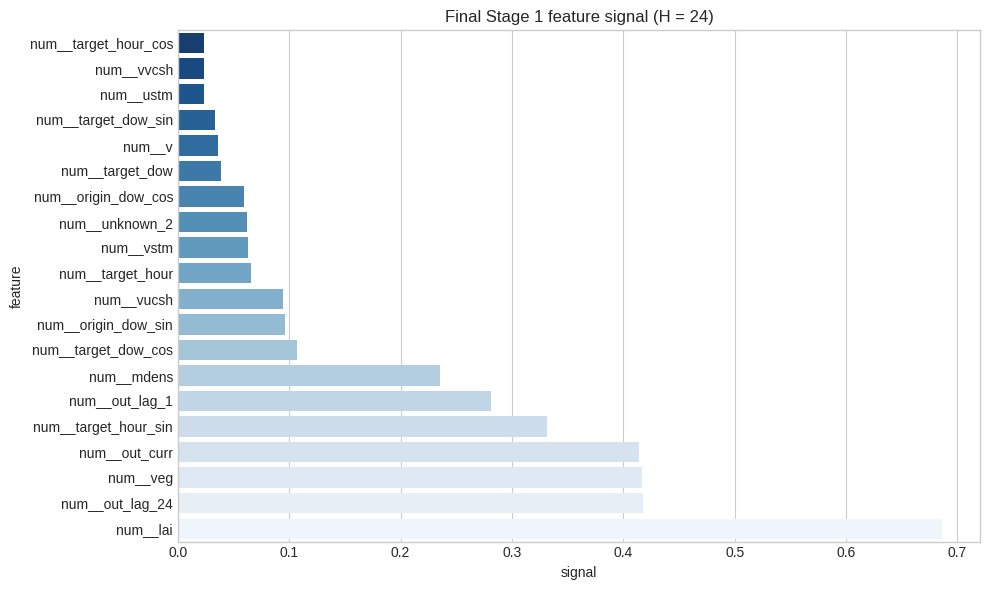

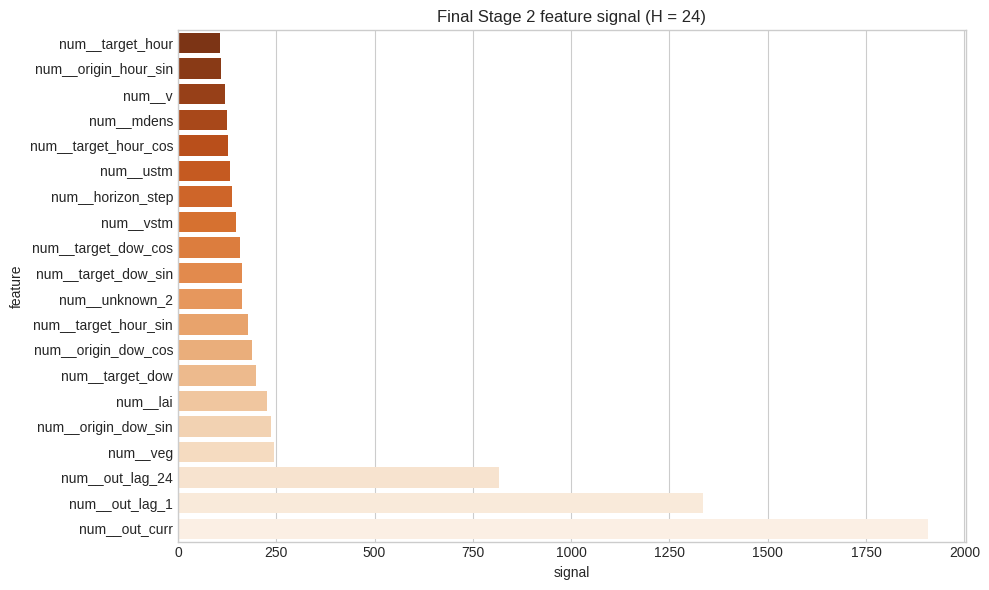

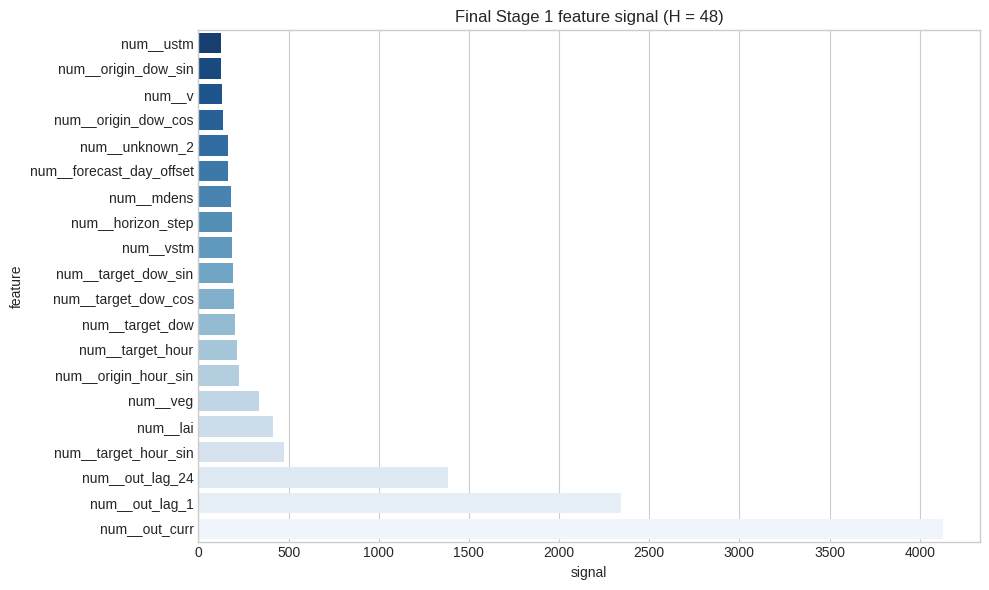

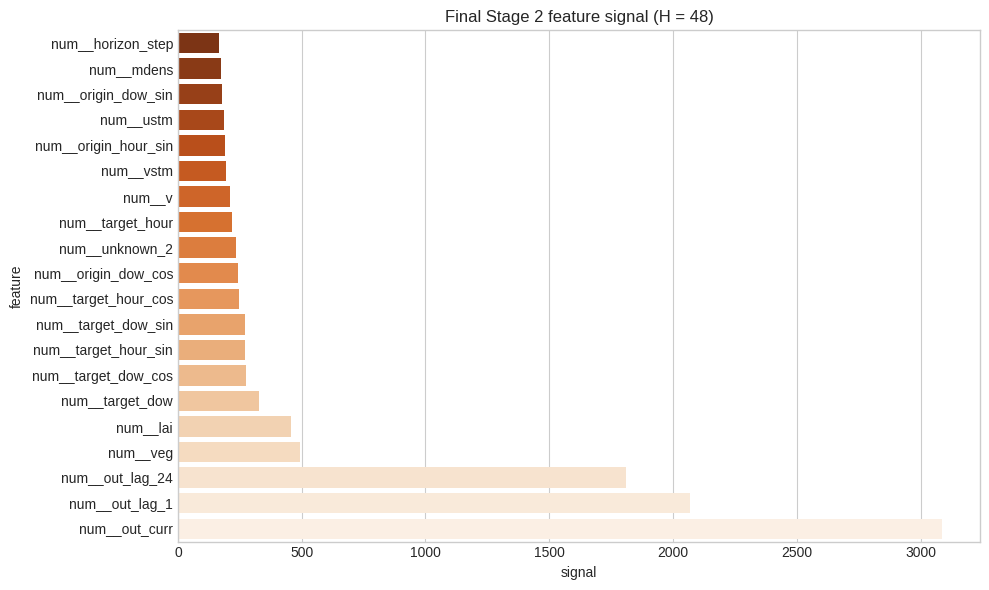

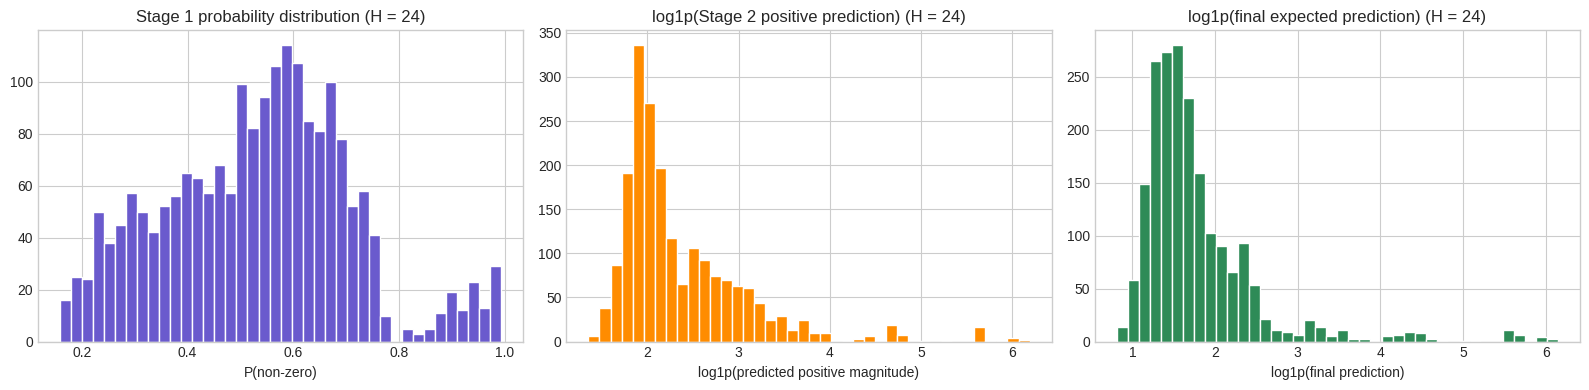

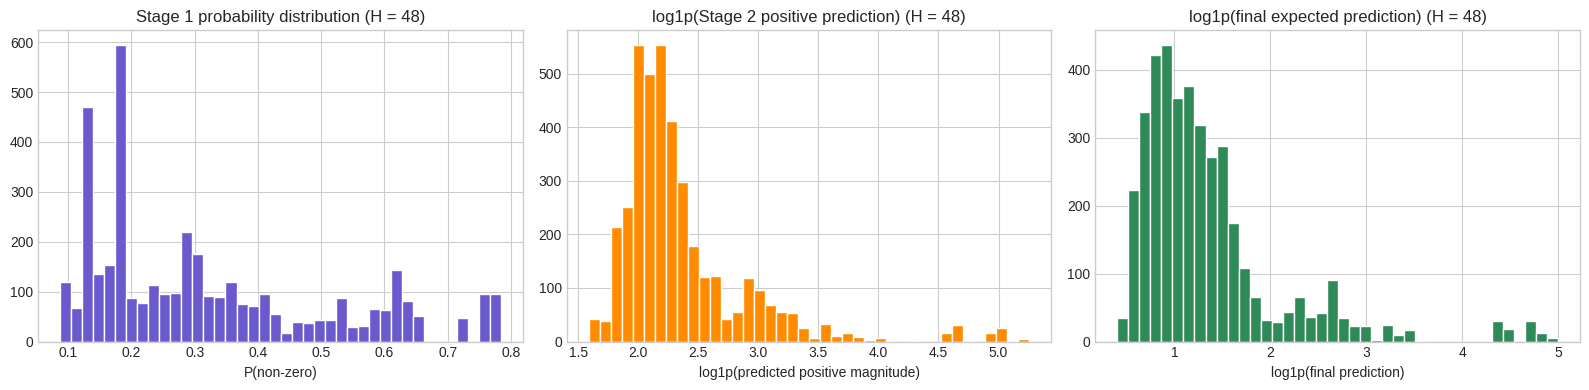

In [17]:
for horizon, bundle in final_model_registry.items():
    stage1_feature_signal = collect_model_feature_signal(bundle['classifier_name'], bundle['stage1']['model'], bundle['stage1']['feature_names'], top_k=20)
    stage2_feature_signal = collect_model_feature_signal(bundle['regressor_name'], bundle['stage2']['model'], bundle['stage2']['feature_names'], top_k=20)

    if not stage1_feature_signal.empty:
        save_dataframe(stage1_feature_signal, ARTIFACT_DIRS['tables'] / f'final_stage1_feature_signal_h{horizon}.csv', index=False)
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=stage1_feature_signal.sort_values('signal', ascending=True), x='signal', y='feature', palette='Blues_r', ax=ax)
        ax.set_title(f'Final Stage 1 feature signal (H = {horizon})')
        plt.tight_layout()
        plt.savefig(ARTIFACT_DIRS['plots'] / f'final_stage1_feature_signal_h{horizon}.png', dpi=140)
        plt.show()

    if not stage2_feature_signal.empty:
        save_dataframe(stage2_feature_signal, ARTIFACT_DIRS['tables'] / f'final_stage2_feature_signal_h{horizon}.csv', index=False)
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(data=stage2_feature_signal.sort_values('signal', ascending=True), x='signal', y='feature', palette='Oranges_r', ax=ax)
        ax.set_title(f'Final Stage 2 feature signal (H = {horizon})')
        plt.tight_layout()
        plt.savefig(ARTIFACT_DIRS['plots'] / f'final_stage2_feature_signal_h{horizon}.png', dpi=140)
        plt.show()

for horizon, prediction_df in [(24, submission_predictions[24]), (48, submission_predictions[48])]:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    axes[0].hist(prediction_df['stage1_proba'], bins=40, color='slateblue', edgecolor='white')
    axes[0].set_title(f'Stage 1 probability distribution (H = {horizon})')
    axes[0].set_xlabel('P(non-zero)')

    axes[1].hist(np.log1p(prediction_df['stage2_positive_pred']), bins=40, color='darkorange', edgecolor='white')
    axes[1].set_title(f'log1p(Stage 2 positive prediction) (H = {horizon})')
    axes[1].set_xlabel('log1p(predicted positive magnitude)')

    axes[2].hist(np.log1p(prediction_df['pred']), bins=40, color='seagreen', edgecolor='white')
    axes[2].set_title(f'log1p(final expected prediction) (H = {horizon})')
    axes[2].set_xlabel('log1p(final prediction)')

    plt.tight_layout()
    plt.savefig(ARTIFACT_DIRS['plots'] / f'prediction_distributions_h{horizon}.png', dpi=140)
    plt.show()


## Manifest and end-of-run summary

The final cell creates a machine-readable manifest so each run is self-describing.

This is helpful when:

- comparing experiments later
- packaging results for a report appendix
- recovering a run after an interruption


In [18]:
artifact_records = []
for path in sorted(RUN_DIR.rglob('*')):
    if path.is_file():
        artifact_records.append(
            {
                'relative_path': str(path.relative_to(RUN_DIR)),
                'size_bytes': int(path.stat().st_size),
                'modified_at': datetime.fromtimestamp(path.stat().st_mtime).isoformat(),
            }
        )

manifest = {
    'run_timestamp': RUN_TIMESTAMP,
    'project_root': str(PROJECT_ROOT),
    'config_path': str((RUN_DIR / 'config.json').relative_to(RUN_DIR)),
    'environment_path': str((RUN_DIR / 'environment.json').relative_to(RUN_DIR)),
    'selected_weather_features': selected_weather_features,
    'best_pair_by_horizon': best_pair_by_horizon.to_dict(orient='records'),
    'best_candidate_model_by_horizon': best_candidate_model_by_horizon.to_dict(orient='records'),
    'final_refit_validation_summary_path': str((ARTIFACT_DIRS['tables'] / 'final_refit_validation_summary.csv').relative_to(RUN_DIR)),
    'submission_model_summary_path': str((ARTIFACT_DIRS['tables'] / 'submission_model_summary.csv').relative_to(RUN_DIR)),
    'artifacts': artifact_records,
}

save_json(manifest, RUN_DIR / 'artifact_manifest.json')

summary_card = pd.DataFrame(
    [
        {
            'run_dir': str(RUN_DIR),
            'n_artifacts': len(artifact_records),
            'best_24h_pair': best_pair_lookup[24]['pair_tag'],
            'best_48h_pair': best_pair_lookup[48]['pair_tag'],
            'submission_24h_model': (
                f"{submission_model_lookup[24]['pair_tag']} | fold {int(submission_model_lookup[24]['fold_id'])}"
                if pd.notna(submission_model_lookup[24]['fold_id'])
                else f"{submission_model_lookup[24]['pair_tag']} | {submission_model_lookup[24]['source']}"
            ),
            'submission_48h_model': (
                f"{submission_model_lookup[48]['pair_tag']} | fold {int(submission_model_lookup[48]['fold_id'])}"
                if pd.notna(submission_model_lookup[48]['fold_id'])
                else f"{submission_model_lookup[48]['pair_tag']} | {submission_model_lookup[48]['source']}"
            ),
            'submission_24h_path': str((ARTIFACT_DIRS['predictions'] / 'two_stage_pred_24h.csv').relative_to(PROJECT_ROOT)),
            'submission_48h_path': str((ARTIFACT_DIRS['predictions'] / 'two_stage_pred_48h.csv').relative_to(PROJECT_ROOT)),
            'final_refit_24h_path': str(final_refit_paths_lookup[24]['prediction'].relative_to(PROJECT_ROOT)),
            'final_refit_48h_path': str(final_refit_paths_lookup[48]['prediction'].relative_to(PROJECT_ROOT)),
        }
    ]
)

display(summary_card)
save_dataframe(summary_card, ARTIFACT_DIRS['tables'] / 'run_summary.csv', index=False)

print('Notebook run preparation is complete.')
print(f'Run directory: {RUN_DIR}')


,run_dir,n_artifacts,best_24h_pair,best_48h_pair,submission_24h_model,submission_48h_model,submission_24h_path,submission_48h_path,final_refit_24h_path,final_refit_48h_path
0,/content/drive/MyDrive/MLPS Project/results/ru...,143,h24__clf_logen01__reg_xgbr01,h48__clf_xgbc01__reg_xgbr01,h24__clf_logen01__reg_xgbr01 | fold 1,h48__clf_xgbc01__reg_xgbr01 | fold 1,results/run_20260419_061735/predictions/two_st...,results/run_20260419_061735/predictions/two_st...,results/run_20260419_061735/predictions/final_...,results/run_20260419_061735/predictions/final_...


Notebook run preparation is complete.
Run directory: /content/drive/MyDrive/MLPS Project/results/run_20260419_061735
